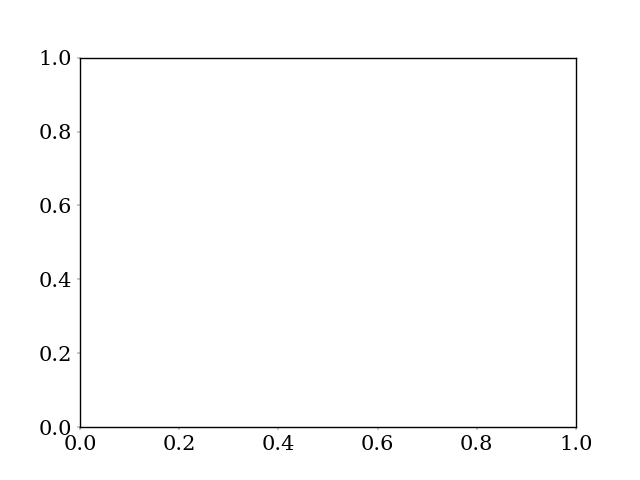

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import networkx as nx
from scipy.special import erfc, gamma,comb,loggamma,gammaln
from tqdm import tqdm
import pickle
import time
import scipy.special as sc
from tqdm import tqdm
import math
from numba import jit, int32,njit, prange
import random
from joblib import Parallel, delayed
from scipy.optimize import curve_fit
from mpmath import stirling2
from scipy.stats import poisson
import scipy.stats as stats
from math import comb, factorial 
from functools import lru_cache



%matplotlib widget
plt.rcParams.update({
        "text.usetex": False,            # Use LaTeX for text rendering
        "font.family": "serif",         # Use a serif font
        "axes.linewidth": 1.5,          # Set axes line width
        "xtick.major.width": 0.3,       # Set x-axis major tick width
        "ytick.major.width": 0.3,       # Set y-axis major tick width
        "xtick.minor.width": 0.3,       # Set x-axis minor tick width
        "ytick.minor.width": 0.3,       # Set y-axis minor tick width
        "axes.labelsize": 15,           # Set label size for axes
        "legend.fontsize": 15,          # Set font size for legend
        "xtick.labelsize": 15,          # Set font size for x-axis labels
        "ytick.labelsize": 15,          # Set font size for y-axis labels
        "xtick.major.size": 2,          # Increase major tick size
        "ytick.major.size": 2,          # Increase major tick size
        "xtick.minor.size": 1,          # Increase minor tick size
        "ytick.minor.size": 1,          # Increase minor tick size
    })
for spine in plt.gca().spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

# --- Waiting time generator ---
@njit
def draw_waiting_time(distribution, lambda_, k, sigma, mu, alpha, x_m):
    if distribution == "exponential":
        return np.random.exponential(1 / lambda_)
    elif distribution == "weibull":
        return np.random.weibull(k) * lambda_
    elif distribution == "lognormal":
        return np.random.lognormal(mu, sigma)
    elif distribution == "pareto":
        return (np.random.pareto(alpha) + 1) * x_m
    elif distribution == "pareto1":
        return (np.random.pareto(alpha + 1) + 1) * x_m
    elif distribution == "pareto2":
        return (np.random.pareto(alpha + 2) + 1) * x_m
    else:
        raise ValueError("Invalid distribution")
# --- Simulate trajectory with plateau detection ---
def simulate_trajectory_with_plateaus(T_max, adj_list, N, dist_type='exponential',
                                      lambda_=1, k=1.5, sigma=1, mu=0, alpha=0.5, x_m=1):
    visited = np.zeros(N, dtype=bool)
    current = np.random.randint(N)
    visited[current] = True

    S_t = [1]
    times = [0.0]
    t = 0.0
    plateau_times = []

    while t < T_max:
        neighbors = adj_list[current]
        if len(neighbors) == 0:
            break
        current = np.random.choice(neighbors)
        dt = draw_waiting_time(dist_type, lambda_, k, sigma, mu, alpha, x_m)
        t += dt

        old_count = np.sum(visited)
        visited[current] = True
        new_count = np.sum(visited)

        S_t.append(new_count)
        times.append(t)

        if new_count == old_count:
            plateau_times.append(t)

    return np.array(times), np.array(S_t), np.array(plateau_times)


def preprocess_graph(G):
    nodes = np.array(G.nodes(), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    E = np.sum(degrees) // 2
    all_neighbors = []
    offsets = [0]

    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))

    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)

    return nodes, degrees, edges_flat, offsets, E

@njit(parallel=True)
def simulate_distinct_counts(T, n_walkers, nodes, edges_flat, offsets, N, rate):
    counts = np.empty(n_walkers, dtype=np.int32)  # stores number of distinct sites per walker
    
    for i in prange(n_walkers):
        current = np.random.randint(N)  # random starting node
        current = 0
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        t = 0.0
        
        while True:
            tau = np.random.exponential(1.0 / rate)  # waiting time until next jump
            if t + tau > T:  # if next jump would exceed total time, stop
                break
            t += tau
            
            start, end = offsets[current], offsets[current + 1]
            if end > start:  # has neighbors
                current = edges_flat[start + np.random.randint(end - start)]
                visited[current] = 1
        
        counts[i] = np.sum(visited)  # total distinct visited sites
    
    return counts



def CCP_distribution(N, rate, T, s_max=None, tol=1e-38):
    lamT = rate * T
    if s_max is None:
        s_max = N
    probs = np.zeros(s_max+1)
    # adaptive Poisson cutoff
    n_max = int(lamT + 50*np.sqrt(lamT))

    for S in range(1, s_max+1):
        total = 0.0
        for n in range(S-1, n_max+1):
            # Skip if Poisson weight already negligible
            Pn = stats.poisson.pmf(n, lamT)
            if Pn < tol:
                break

            stir = stirling2(n, S-1)
            if stir == 0:
                continue

            # log(prob_v) = log(C(N-1,S-1)) + log((S-1)!) + log(stir) - n*log(N-1)
            log_comb = gammaln(N) - gammaln(S) - gammaln(N-S+1)
            log_fact = gammaln(S)
            log_stir = math.log(stir)
            log_denom = n * math.log(N-1)

            log_prob_v = log_comb + log_fact + log_stir - log_denom
            prob_given_n = math.exp(log_prob_v)

            total += prob_given_n * Pn

        probs[S] = total

    return probs

@njit
def simulate_path_fixed_n(n, nodes, edges_flat, offsets, N):
    current = np.random.randint(0, N)
    visited = np.zeros(N, dtype=np.int8)
    visited[current] = 1
    visited_count = 1
    for _ in range(n):
        start,end = offsets[current],offsets[current + 1]
        if end > start:
            idx = start + np.random.randint(0, end - start)
            current = edges_flat[idx]
            if visited[current] == 0:
                visited[current] = 1
                visited_count += 1
    return visited_count
def importance_sampling(total_samples, mu, tilde_mu, nodes, edges_flat, offsets, N, S_max):
    weighted_counts = np.zeros(S_max + 1, dtype=np.float64)
    total_weight = 0.0
    
    for _ in range(total_samples):
        n = np.random.poisson(tilde_mu)
        S = simulate_path_fixed_n(n, nodes, edges_flat, offsets, N)
        if mu == 0:
            if n == 0:
                w = 1.0
            else:
                w = 0.0
        else:
            w = math.exp(-(mu - tilde_mu) + n * (math.log(mu) - math.log(tilde_mu)))
        if S <= S_max:
            weighted_counts[S] += w
        total_weight += w
    P_hat = weighted_counts / total_weight
    return P_hat, total_weight
@lru_cache(None)
def stirling2(n, k):
    """Stirling number of the second kind S(n, k)."""
    if n == k == 0:
        return 1
    if n == 0 or k == 0:
        return 0
    if k > n:
        return 0
    return k * stirling2(n-1, k) + stirling2(n-1, k-1)

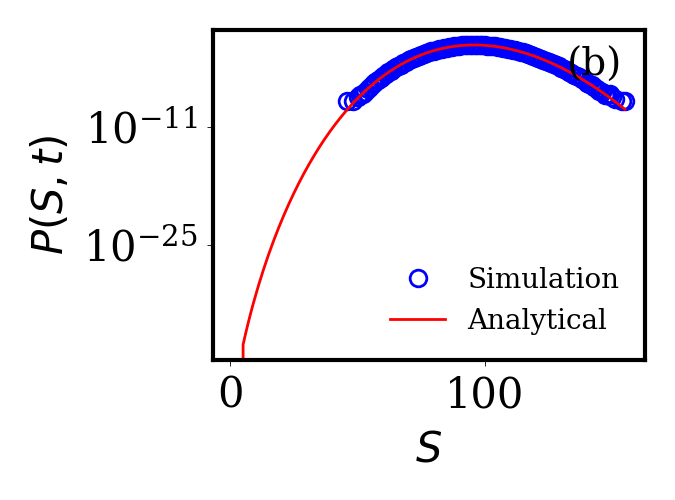

In [86]:
#figure 2,3
# Graph parameters
N = 1000
p = 0.01

# Walker simulation parameters
n_walkers = 10**8
rate = 2.0  # λ=2 => ψ(τ) = 2 e^{-2τ}
T_fixed = 50
r,h=3,5
m=3
# Generate connected ER graph
while True:
    #G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,)
    #G = nx.cycle_graph(N)
    G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets, E = preprocess_graph(G)
N=len(nodes)
visited_counts = simulate_distinct_counts(T_fixed, n_walkers, nodes, edges_flat, offsets, N, rate)

plt.figure(figsize=(3.375, 2.5),dpi=200)
# Simulated histogram
max_visits = max(visited_counts)
x=np.bincount(visited_counts,minlength=max_visits+1)
hist=x/np.sum(x)

v_vals = np.arange(1, max_visits + 1)
n_vals = v_vals-1
#P_analytical = stats.poisson.pmf(n_vals, mu=rate * T_fixed)  # ← fixed here
ax=plt.gca()
P_ccp = CCP_distribution(N, rate, T_fixed, max_visits)
plt.semilogy(np.arange(1, len(hist)), hist[1:], 'bo', mfc="none", label='Simulation')
plt.semilogy(np.arange(1, len(P_ccp)), P_ccp[1:], 'r-', label='Analytical', lw=1)
plt.text(0.82, 0.95, "(b)", transform=ax.transAxes, fontsize=14, va='top')
#plt.semilogy(v_vals, P_analytical, 'r-', color='g', label=' (Poisson shifted)', lw=2)
plt.xlabel(r"$S$")
plt.ylabel("$P(S,t)$")
plt.legend(frameon=False,fontsize=10)
plt.tight_layout()
plt.show()

In [83]:
#t=1
plt.xticks([0,5,10,15,20])
plt.yticks([.1,0.001,0.00001,.0000001,0.000000001])
plt.xlim(0,19)
plt.ylim(0.000000001,0.8)
plt.tight_layout()

In [87]:
#t=50
plt.xticks([50,75,100,125,150,175])
plt.yticks([.1,0.001,0.00001,.0000001,0.000000001])
plt.xlim(38,159)
plt.ylim(0.000000001,0.8)
plt.tight_layout()

In [63]:
plt.savefig(f"./fig/ER_network_N_{N}_P_point01_t_{T_fixed}_rate_2.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [88]:
plt.savefig(f"./fig/complete_network_N_{N}_t_{T_fixed}_rate_2.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

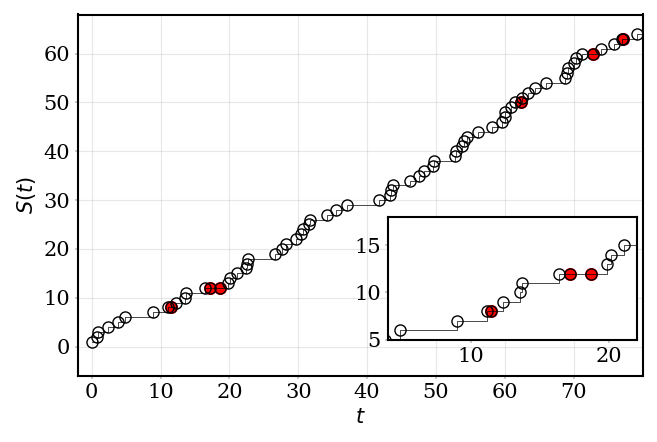

In [2]:

#figure 1
N=1000
data = np.load(f"walker_data_ER{N}1.npz")
t_exp = data["t"]
S_exp = data["S"]
plateau_exp = data["plateaus"]

fig, ax = plt.subplots(figsize=(6.575, 4.425))
ax.step(t_exp, S_exp, where='post', color='k', lw=0.5, marker='o',markersize=8, linestyle='-',
        label=r'exponential', mfc='none', mec='k')
ax.scatter(plateau_exp, [S_exp[np.searchsorted(t_exp, pt)] for pt in plateau_exp],
           color='red', s=70, marker='o',)

ax.set_xlabel(r"$t$")
ax.set_ylim(-6,68)
ax.set_xticks([0,10,20,30,40,50,60,70])

ax.set_xlim(-2,80)
ax.set_ylabel(r"$S(t)$")
ax.grid(True, alpha=0.3)
ax_inset = ax.inset_axes([0.55, 0.10, 0.44, 0.34])
ax_inset.step(t_exp, S_exp, color='k',where='post', lw=0.5, marker='o',markersize=8, mfc='none', mec='k')
ax_inset.scatter(plateau_exp, [S_exp[np.searchsorted(t_exp, pt)] for pt in plateau_exp],
        color='red', s=70, marker='o')
ax_inset.set_xlim(4,22)
ax_inset.set_ylim(5,18)
plt.tight_layout()
#plt.savefig("./fig/walker_plateau_plot_t=1_lambda_2_N_1000_co_point1.pdf", dpi=200, format='pdf',
#            bbox_inches='tight', pad_inches=0.02)

IS done, total weight: 10000000.0 time: 33.34747338294983


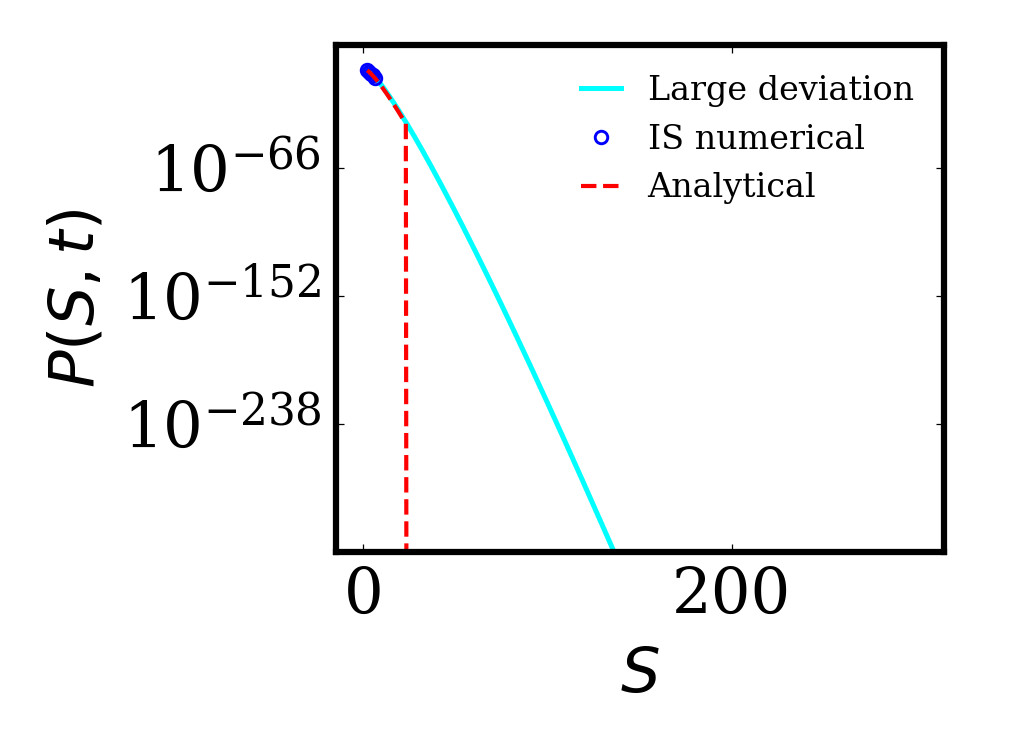

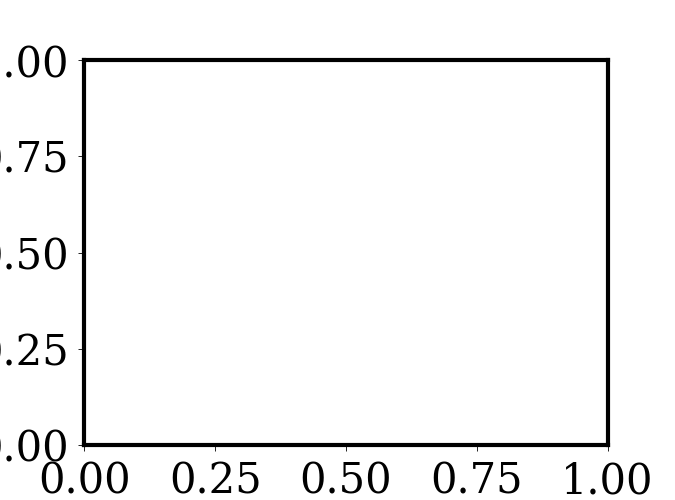

In [4]:
    #figure 4
    N = 1000
    p = 0.1
    while True:
        #G = nx.erdos_renyi_graph(N, p)
        #G = nx.barabasi_albert_graph(N, m,)
        #G = nx.cycle_graph(N)
        G = nx.complete_graph(N)
        #G = nx.balanced_tree(r,h)
        
        if nx.is_connected(G):
            break
    nodes, degrees, edges_flat, offsets, E = preprocess_graph(G)
    T=0.1
    lambda_=2
    mu=lambda_ *T
    tilde_mu = mu + 0
    total_samples = 10000000
    S_max = 300
    
    t0 = time.time()
    P_hat, tot_w = importance_sampling(total_samples, mu, tilde_mu, nodes, edges_flat, offsets, N, S_max)
    print("IS done, total weight:", tot_w, "time:", time.time() - t0)
    
    # Analytical comparison
    S_vals = np.arange(0, S_max+1)
    shift = 1
    n_vals = S_vals - shift
    anal = np.zeros_like(S_vals, dtype=float)
    mask = (n_vals >= 0)
    anal[mask] = stats.poisson.pmf(n_vals[mask], mu=mu)
    P_ccp = CCP_distribution(N,lambda_, T,S_max)
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(3.375, 2.5),dpi=200)  # PRL single-column figure size
    laa_ = (n_vals-1) / T
    mask = laa_ > 0
    I = np.zeros_like(laa_)
    I[mask] = laa_[mask] * np.log(laa_[mask] / lambda_) - laa_[mask] + lambda_
    lg = np.exp(-I * T)

    fig, ax = plt.subplots(figsize=(3.375, 2.5), dpi=300)

    ax.semilogy(S_vals[:-1], lg[1:], '-', color='cyan', lw=1.2, label='Large deviation')
    ax.semilogy(S_vals[2:], P_hat[2:], 'o', ms=3, mfc='none', mec='b', mew=0.7, label='IS numerical')
    ax.semilogy(S_vals[2:], P_ccp[2:], '--', lw=1.0, color='r', label='Analytical')

    ax.set_xlabel(r"$S$")
    ax.set_ylabel(r"$P(S,t)$")
    ax.legend(frameon=False, loc='upper right', fontsize=8, handlelength=1.2)
    ax.tick_params(direction='in', top=True, right=True)
    plt.tight_layout()
    plt.show()

In [67]:
plt.savefig(f"./fig/complete_network_N_1000_P_point1_t_1_rate_2__mutilde_12_sample_100000.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [ ]:
plt.savefig(f"./fig/ER_network_N_{N}_P_point1_t_{T}_rate_{lambda_}.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

N= 1093


/tmp/ipykernel_142087/1159795852.py:117: RuntimeWarning: divide by zero encountered in log
  I = lambda_ * np.log(lambda_ / rate) - lambda_ + rate
/tmp/ipykernel_142087/1159795852.py:117: RuntimeWarning: invalid value encountered in multiply
  I = lambda_ * np.log(lambda_ / rate) - lambda_ + rate


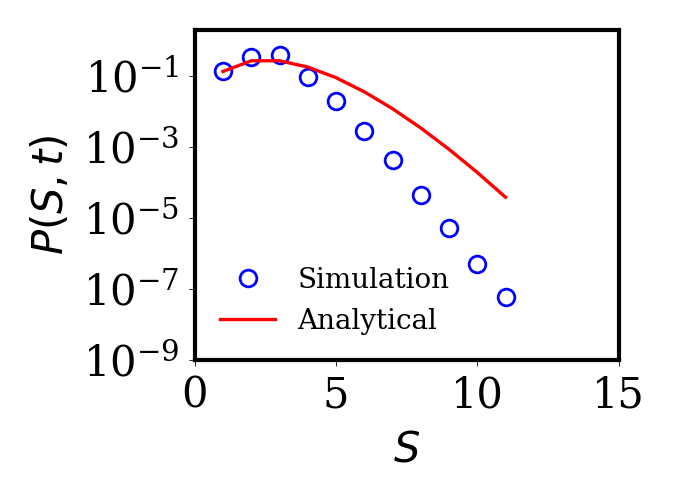

Total time: 5.07 seconds


In [32]:
#different N for the complete graph,ba,er,cycle,for the different time poisson shifted 

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import scipy.stats as stats
import math
import time


def preprocess_graph(G):
    nodes = np.array(G.nodes(), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    E = np.sum(degrees) // 2
    all_neighbors = []
    offsets = [0]

    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))

    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)

    return nodes, degrees, edges_flat, offsets, E

@njit(parallel=True)
def simulate_distinct_counts(T, n_walkers, nodes, edges_flat, offsets, N, rate):
    counts = np.empty(n_walkers, dtype=np.int32)  # stores number of distinct sites per walker
    
    for i in prange(n_walkers):
        #current = np.random.randint(N)  # random starting node
        current = 99
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        t = 0.0
        
        while True:
            tau = np.random.exponential(1.0 / rate)  # waiting time until next jump
            if t + tau > T:  # if next jump would exceed total time, stop
                break
            t += tau
            
            start, end = offsets[current], offsets[current + 1]
            if end > start:  # has neighbors
                current = edges_flat[start + np.random.randint(end - start)]
                visited[current] = 1
        
        counts[i] = np.sum(visited)  # total distinct visited sites
    
    return counts


# ===============================
#  Rate function for Poisson LDP
# ===============================
def rate_function(r, lam):
    """I(r) = r log(r/lambda) - r + lambda"""
    if r <= 0:
        return np.inf
    return r * np.log(r / lam) - r + lam

# ===============================
#  LDP and refined approximations
# ===============================
def Q_ldp(t, n, lam):
    r = n / t
    I = rate_function(r, lam)
    return np.exp(-t * I)

def Q_refined(t, n, lam):
    r = n / t
    I = rate_function(r, lam)
    pref = 1.0 / np.sqrt(2 * np.pi * r * t)
    return pref * np.exp(-t * I)

# Graph parameters
N = 1000
p = 0.01

# Walker simulation parameters
n_walkers = 10**8
rate = 2.0  # λ=2 => ψ(τ) = 2 e^{-2τ}
T_fixed = 1
r,h=3,6
m=4
# Generate connected ER graph
while True:
    #G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,seed=4)
    #G = nx.cycle_graph(N)
    #G = nx.complete_graph(N)
    G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets, E = preprocess_graph(G)
N=len(G.nodes())
print("N=",N)
visited_counts = simulate_distinct_counts(T_fixed, n_walkers, nodes, edges_flat, offsets, N, rate)

plt.figure(figsize=(3.375, 2.5),dpi=200)
# Simulated histogram
max_visits = max(visited_counts)
x=np.bincount(visited_counts,minlength=max_visits+1)
hist=x/np.sum(x)

plt.semilogy(np.arange(1, len(hist)), hist[1:], 'bo', mfc="none",label='Simulation')

v_vals = np.arange(1, max_visits +1)
n_vals = v_vals-1
P_analytical = stats.poisson.pmf(n_vals, mu=rate * T_fixed)  # ← fixed here
lambda_ = (v_vals-1) / T_fixed

I = lambda_ * np.log(lambda_ / rate) - lambda_ + rate
prefactor= 1/np.sqrt(2*(np.pi)*rate*T_fixed)
lg =prefactor*np.exp(-I * T_fixed)
lgg =np.exp(-I * T_fixed)
#plt.semilogy(v_vals, lgg, color='magenta', lw=1.2, label='Large deviation')
#plt.semilogy(v_vals, lg, color='cyan', lw=1.2, label='Large deviation')

plt.semilogy(v_vals, P_analytical, color='r', lw=1.2, label='Analytical')
plt.ylabel(r"$P(S, t)$")
plt.xlabel(r"$S$")
plt.xticks([0,5,10,15])
plt.yticks([.1,0.001,0.00001,0.0000001,0.000000001])
plt.ylim(0.000000001,2)
plt.legend(frameon=False,fontsize=10)
plt.tight_layout()
plt.show()
print(f"Total time: {time.time() - start_time:.2f} seconds")

In [23]:
plt.savefig(f"./fig/ER_N_{N}_P_point1_t_{T_fixed}_rate_2_poission.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [27]:
 plt.savefig(f"./fig/Cicle_N_{N}_t_point1_rate_2__walker_100000000.pdf", format='pdf',
           bbox_inches='tight', pad_inches=0.03)

In [ ]:
ER_network_N_1000_P_point01_t_50_rate_2.pdf

In [29]:
 plt.savefig(f"./fig/CT_N_{N}_r_3_h_6_t_point1_rate_2__walker_100000000.pdf", format='pdf',
           bbox_inches='tight', pad_inches=0.03)

In [31]:
plt.savefig(f"./fig/BA_N_1000_m_4_t_point1_rate_2__walker_10000000000.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [25]:
plt.savefig(f"./fig/ER_N_1000_P_point01_t_point1_rate_2__walker_100000000.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [ ]:
lambda_=(S-1)/t
I=lambda_*np.ln(lambda_/rate)-lambda_+rate
lg=np.exp(-I*t)

/home/sarvesh/venvs/cleanenv/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/tmp/ipykernel_35636/3427658696.py:88: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro--" (-> color='r'). The keyword argument will take precedence.
  plt.semilogy(v_vals, P_analytical, 'ro--', color='r', label='Analytical (Poisson shifted)', lw=2)


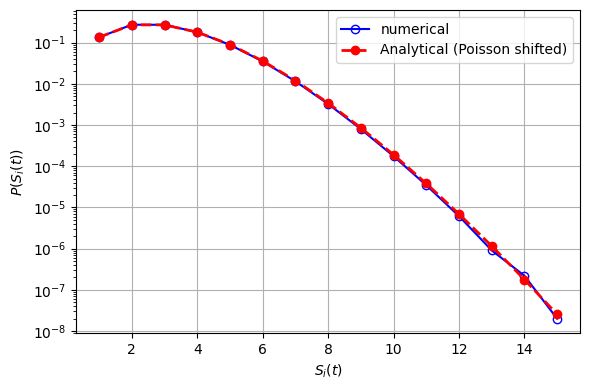

Total time: 6.53 seconds


In [1]:
#navie simulation 
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import scipy.stats as stats
import math
import time


def preprocess_graph(G):
    nodes = np.array(G.nodes(), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    E = np.sum(degrees) // 2
    all_neighbors = []
    offsets = [0]

    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))

    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)

    return nodes, degrees, edges_flat, offsets, E

@njit(parallel=True)
def simulate_distinct_counts(T, n_walkers, nodes, edges_flat, offsets, N, rate):
    counts = np.empty(n_walkers, dtype=np.int32)  # stores number of distinct sites per walker
    
    for i in prange(n_walkers):
        current = np.random.randint(N)  # random starting node
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        t = 0.0
        
        while True:
            tau = np.random.exponential(1.0 / rate)  # waiting time until next jump
            if t + tau > T:  # if next jump would exceed total time, stop
                break
            t += tau
            
            start, end = offsets[current], offsets[current + 1]
            if end > start:  # has neighbors
                current = edges_flat[start + np.random.randint(end - start)]
                visited[current] = 1
        
        counts[i] = np.sum(visited)  # total distinct visited sites
    
    return counts




# Graph parameters
N = 1000
p = 0.1

# Walker simulation parameters
n_walkers = 10**8
rate = 2.0  # λ=2 => ψ(τ) = 2 e^{-2τ}
T_fixed = 1.0

# Generate connected ER graph
while True:
    G = nx.erdos_renyi_graph(N, p)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets, E = preprocess_graph(G)
visited_counts = simulate_distinct_counts(T_fixed, n_walkers, nodes, edges_flat, offsets, N, rate)

plt.figure(figsize=(6, 4))
# Simulated histogram
max_visits = max(visited_counts)
x=np.bincount(visited_counts,minlength=max_visits+1)
hist=x/np.sum(x)

plt.semilogy(np.arange(1, len(hist)), hist[1:], 'bo-', mfc="none",label='numerical')

v_vals = np.arange(1, max_visits + 1)
n_vals = v_vals-1
P_analytical = stats.poisson.pmf(n_vals, mu=rate * T_fixed)  # ← fixed here

# Plot both

plt.semilogy(v_vals, P_analytical, 'ro--', color='r', label='Analytical (Poisson shifted)', lw=2)

plt.xlabel(r"$S_i(t)$")
plt.ylabel("$P(S_i(t))$")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Total time: {time.time() - start_time:.2f} seconds")

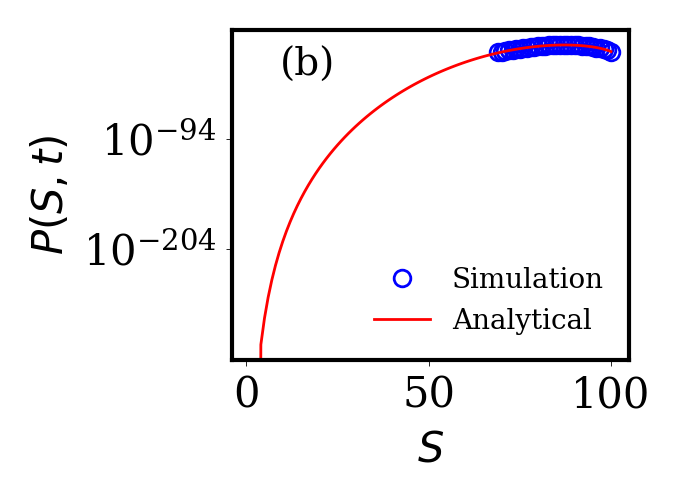

In [92]:
#descrete waiting time
#figure 2
import math
from scipy.special import comb
import numpy as np
import math
from mpmath import stirling2
from scipy.stats import poisson
from scipy.special import comb
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import scipy.stats as stats
import math

from math import comb, factorial
from scipy.special import comb, loggamma
from functools import lru_cache
import math
from scipy.special import gammaln
import time


def preprocess_graph(G):
    nodes = np.array(G.nodes(), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    E = np.sum(degrees) // 2
    all_neighbors = []
    offsets = [0]

    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))

    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)

    return nodes, degrees, edges_flat, offsets, E

@njit(parallel=True)
def simulate_distinct_counts_discrete(T, n_walkers, nodes, edges_flat, offsets, N):
    counts = np.empty(n_walkers, dtype=np.int32)  # stores number of distinct sites per walker
    
    for i in prange(n_walkers):
        #current = np.random.randint(N)  # random starting node
        current =0
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        
        for _ in range(T):  # exactly T steps
            start, end = offsets[current], offsets[current + 1]
            if end > start:  # has neighbors
                current = edges_flat[start + np.random.randint(end - start)]
                visited[current] = 1
        
        counts[i] = np.sum(visited)  # total distinct visited sites
    return counts

def CCP_discrete(N, T, s_max=None):
    if s_max is None:
        s_max = N
    probs = np.zeros(s_max+1)
    
    for S in range(1, s_max+1):
        stir = stirling2(T, S-1, exact=True)
        if stir == 0:
            continue
        
        log_comb = gammaln(N) - gammaln(S) - gammaln(N-S+1)   # log(C(N-1, S-1))
        log_fact = gammaln(S)                                # log((S-1)!)
        log_stir = math.log(stir)
        log_denom = T * math.log(N-1)
        
        log_prob = log_comb + log_fact + log_stir - log_denom
        probs[S] = math.exp(log_prob)
    
    return probs



# Graph parameters
N = 100
p = 0.1

# Walker simulation parameters
n_walkers = 10**8
rate = 2.0  # λ=2 => ψ(τ) = 2 e^{-2τ}
T_fixed = 200
r,h=3,5
m=3
# Generate connected ER graph
while True:
    #G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,)
    #G = nx.cycle_graph(N)
    G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets, E = preprocess_graph(G)
N=len(nodes)
# Run discrete-time simulation
visited_counts = simulate_distinct_counts_discrete(T_fixed, n_walkers, nodes, edges_flat, offsets, N)

# Histogram from simulation
max_visits = max(visited_counts)
x = np.bincount(visited_counts, minlength=max_visits+1)
hist = x / np.sum(x)

# Analytical
P_ccp = CCP_discrete(N, T_fixed, max_visits)


plt.figure(figsize=(3.375, 2.5), dpi=200)
ax=plt.gca()
plt.semilogy(np.arange(1, len(hist)), hist[1:], 'bo', mfc="none", label='Simulation')
plt.text(0.12, 0.95, "(b)", transform=ax.transAxes, fontsize=14, va='top')
plt.semilogy(np.arange(1, len(P_ccp)), P_ccp[1:], 'r-', label='Analytical', lw=1)
plt.xlabel(r"$S$")
plt.ylabel(r"$P(S, t)$")
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


In [90]:
#t=30
plt.xticks([10,15,20,25,30,35])
plt.yticks([.1,0.001,0.00001,.0000001,0.000000001])
plt.xlim(14,32)
plt.ylim(0.000000001,0.8)
plt.tight_layout()


In [94]:
#t=200
plt.xticks([70,80,90,100])
#plt.xticks([2,4,6,8,10,12,14])
plt.yticks([.1,0.001,0.00001,.0000001,0.000000001])
plt.xlim(64,103)
plt.ylim(0.000000001,0.8)
plt.tight_layout()


In [95]:
plt.tight_layout()
plt.savefig(f"./fig/complete_network_N_{N}_t_{T_fixed}_discrete.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

/tmp/ipykernel_187778/3056459842.py:15: RuntimeWarning: overflow encountered in long_scalars
  return k * stirling2(n-1, k) + stirling2(n-1, k-1)


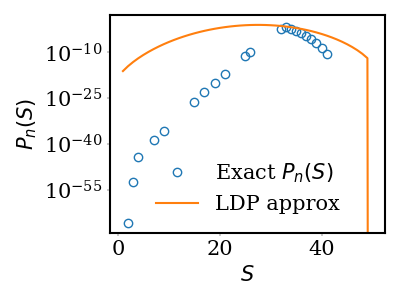

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb
from math import factorial, log
from functools import lru_cache

# ---- Stirling numbers of the second kind ----
@lru_cache(None)
def stirling2(n, k):
    """Compute Stirling numbers of the second kind recursively."""
    if n == k == 0:
        return 1
    if n == 0 or k == 0:
        return 0
    return k * stirling2(n-1, k) + stirling2(n-1, k-1)

# ---- Exact combinatorial probability ----
def Pn_exact(N, n, S):
    if S < 1 or S > N:
        return 0
    num = comb(N-1, S-1) * factorial(S-1) * stirling2(n, S-1)
    denom = (N-1)**n
    return num / denom

# ---- Rate function for large-deviation approx ----
def rate_function(x, rho):
    # Derived rate function for occupancy-type random walk
    # I(x; rho) = x ln(x/rho) + (1-x) ln((1-x)/(1 - e^{-rho}))
    # but use a version consistent with random walk exploration:
    if x <= 0 or x >= 1:
        return np.inf
    return x * np.log(x / (1 - np.exp(-rho))) + (1 - x) * np.log((1 - x) / np.exp(-rho))

def Pn_ldp(N, n, S):
    rho = n / N
    x = S / N
    I = rate_function(x, rho)
    return np.exp(-N * I)

# ---- Parameters ----
N = 50
n = 40
S_vals = np.arange(1, N + 1)

P_exact = np.array([Pn_exact(N, n, S) for S in S_vals])
P_ldp = np.array([Pn_ldp(N, n, S) for S in S_vals])
P_ldp /= np.sum(P_ldp)  # normalize to compare properly

# ---- Plot ----
plt.figure(figsize=(4, 3))
plt.plot(S_vals, P_exact, 'o', mfc='none', label='Exact $P_n(S)$')
plt.plot(S_vals, P_ldp, '-', lw=1.5, label='LDP approx')
plt.xlabel('$S$')
plt.ylabel('$P_n(S)$')
plt.yscale('log')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


/tmp/ipykernel_187778/580511698.py:26: RuntimeWarning: divide by zero encountered in double_scalars
  pref = 1.0 / np.sqrt(2 * np.pi * r * t)
/tmp/ipykernel_187778/580511698.py:27: RuntimeWarning: invalid value encountered in double_scalars
  return pref * np.exp(-t * I)


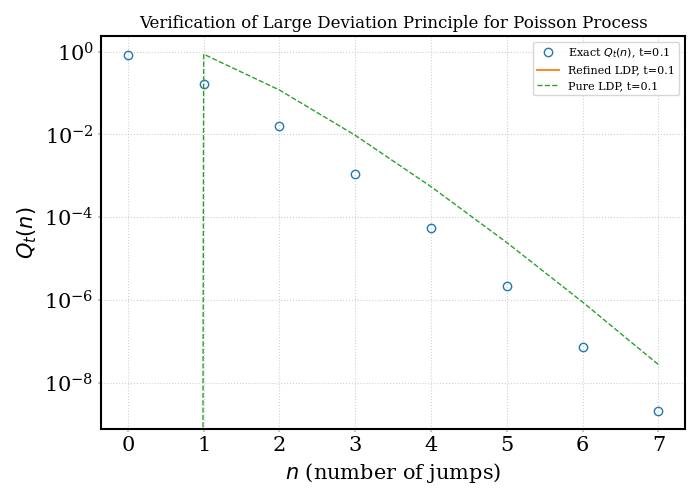

Max relative error (refined LDP) at t=0.1: nan
Max relative error (pure LDP) at t=0.1: 5.226e+00


/tmp/ipykernel_187778/580511698.py:26: RuntimeWarning: invalid value encountered in sqrt
  pref = 1.0 / np.sqrt(2 * np.pi * r * t)


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp, factorial
from scipy.stats import poisson

# ===============================
#  Rate function for Poisson LDP
# ===============================
def rate_function(r, lam):
    """I(r) = r log(r/lambda) - r + lambda"""
    if r <= 0:
        return np.inf
    return r * np.log(r / lam) - r + lam

# ===============================
#  LDP and refined approximations
# ===============================
def Q_ldp(t, n, lam):
    r = n / t
    I = rate_function(r, lam)
    return np.exp(-t * I)

def Q_refined(t, n, lam):
    r = n / t
    I = rate_function(r, lam)
    pref = 1.0 / np.sqrt(2 * np.pi * r * t)
    return pref * np.exp(-t * I)

# ===============================
#  Verification parameters
# ===============================
lam = 2.0               # exponential rate
t_values = [0.1] # different times
plt.figure(figsize=(7, 5))

for t in t_values:
    m = lam * t
    n_vals = np.arange(max(0, int(m - 16*np.sqrt(m))), int(m + 16*np.sqrt(m)) + 1)
    
    # Exact Poisson distribution
    Q_exact = poisson.pmf(n_vals, mu=m)
    
    # LDP approximations
    Q_ldp_vals = np.array([Q_ldp(t, n, lam) for n in n_vals])
    Q_ref_vals = np.array([Q_refined(t, n, lam) for n in n_vals])
    
    # Normalize approximations to make shapes comparable
    Q_ldp_vals /= np.sum(Q_ldp_vals)
    Q_ref_vals /= np.sum(Q_ref_vals)
    
    # Plot
    plt.plot(n_vals, Q_exact, 'o', mfc='none', label=f'Exact $Q_t(n)$, t={t}')
    plt.plot(n_vals, Q_ref_vals, '-', lw=1.3, label=f'Refined LDP, t={t}')
    plt.plot(n_vals, Q_ldp_vals, '--', lw=1.0, label=f'Pure LDP, t={t}')

plt.yscale('log')
plt.xlabel('$n$ (number of jumps)')
plt.ylabel('$Q_t(n)$')
plt.title('Verification of Large Deviation Principle for Poisson Process')
plt.legend(fontsize=8)
plt.grid(True, which='both', ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ===============================
#  Numeric comparison for largest t
# ===============================
t = t_values[-1]
m = lam * t
n_vals = np.arange(int(m - 15*np.sqrt(m)), int(m + 15*np.sqrt(m)) + 1)
Q_exact = poisson.pmf(n_vals, mu=m)
Q_ref_vals = np.array([Q_refined(t, n, lam) for n in n_vals])
Q_ldp_vals = np.array([Q_ldp(t, n, lam) for n in n_vals])

rel_err_ref = np.max(np.abs(Q_exact - Q_ref_vals) / (Q_exact + 1e-30))
rel_err_ldp = np.max(np.abs(Q_exact - Q_ldp_vals) / (Q_exact + 1e-30))

print(f"Max relative error (refined LDP) at t={t}: {rel_err_ref:.3e}")
print(f"Max relative error (pure LDP) at t={t}: {rel_err_ldp:.3e}")


In [24]:
plt.plot(n_vals, Q_ref_vals, '-', lw=1.3, label=f'Refined LDP, t={t}')

N= 1000


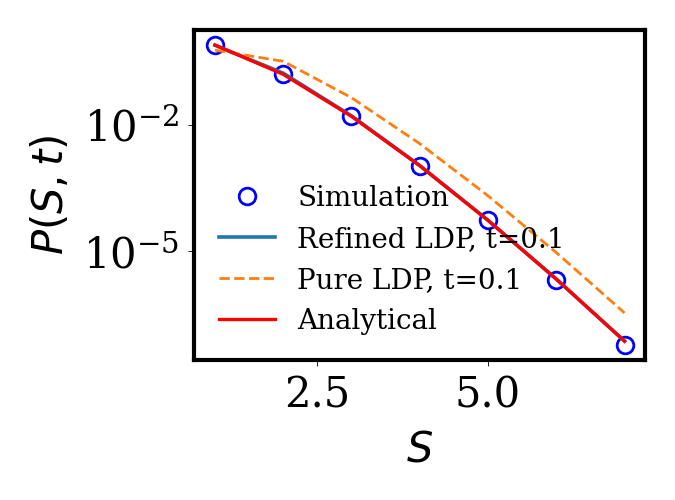

Total time: 5.09 seconds


In [30]:
#different N for the complete graph,ba,er,cycle,for the different time poisson shifted 

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import scipy.stats as stats
import math
import time


def preprocess_graph(G):
    nodes = np.array(G.nodes(), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    E = np.sum(degrees) // 2
    all_neighbors = []
    offsets = [0]

    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))

    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)

    return nodes, degrees, edges_flat, offsets, E

@njit(parallel=True)
def simulate_distinct_counts(T, n_walkers, nodes, edges_flat, offsets, N, rate):
    counts = np.empty(n_walkers, dtype=np.int32)  # stores number of distinct sites per walker
    
    for i in prange(n_walkers):
        #current = np.random.randint(N)  # random starting node
        current = 99
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        t = 0.0
        
        while True:
            tau = np.random.exponential(1.0 / rate)  # waiting time until next jump
            if t + tau > T:  # if next jump would exceed total time, stop
                break
            t += tau
            
            start, end = offsets[current], offsets[current + 1]
            if end > start:  # has neighbors
                current = edges_flat[start + np.random.randint(end - start)]
                visited[current] = 1
        
        counts[i] = np.sum(visited)  # total distinct visited sites
    
    return counts


# ===============================
#  Rate function for Poisson LDP
# ===============================
def rate_function(r, lam):
    """I(r) = r log(r/lambda) - r + lambda"""
    if r <= 0:
        return np.inf
    return r * np.log(r / lam) - r + lam

# ===============================
#  LDP and refined approximations
# ===============================
def Q_ldp(t, n, lam):
    if n == 0:
        return math.exp(-t * lam)
    r = n / t
    I = rate_function(r, lam)
    return np.exp(-t * I)
def Q_refined(t, n, lam):
    # refined saddle prefactor; handle n==0 exactly
    if n == 0:
        return math.exp(-t * lam)   # exact for n=0 (Poisson P(0))
    r = n / t
    I = rate_function(r, lam)
    pref = 1.0 / math.sqrt(2.0 * math.pi * r * t)
    return pref * math.exp(-t * I)
# Graph parameters
N = 1000
p = 1

# Walker simulation parameters
n_walkers = 10**8
rate = 2.0  # λ=2 => ψ(τ) = 2 e^{-2τ}
T_fixed = 0.1
r,h=3,6
m=4
# Generate connected ER graph
while True:
    #G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,seed=4)
    #G = nx.cycle_graph(N)
    G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets, E = preprocess_graph(G)
N=len(G.nodes())
print("N=",N)
visited_counts = simulate_distinct_counts(T_fixed, n_walkers, nodes, edges_flat, offsets, N, rate)

plt.figure(figsize=(3.375, 2.5),dpi=200)
# Simulated histogram
max_visits = max(visited_counts)
x=np.bincount(visited_counts,minlength=max_visits+1)
hist=x/np.sum(x)

plt.semilogy(np.arange(1, len(hist)), hist[1:], 'bo', mfc="none",label='Simulation')

v_vals = np.arange(1, max_visits +1)
n_vals = v_vals-1
P_analytical = stats.poisson.pmf(n_vals, mu=rate * T_fixed)  # ← fixed here

# LDP approximations
Q_ldp_vals = np.array([Q_ldp(T_fixed, n, rate) for n in n_vals])
Q_ref_vals = np.array([Q_refined(T_fixed, n, rate) for n in n_vals])
    
# Normalize approximations to make shapes comparable
Q_ldp_vals /= np.sum(Q_ldp_vals)
Q_ref_vals /= np.sum(Q_ref_vals)
    
    # Plot
#plt.plot(n_vals, Q_exact, 'o', mfc='none', label=f'Exact $Q_t(n)$, t={t}')
plt.plot(v_vals, Q_ref_vals, '-', lw=1.3, label=f'Refined LDP, t={t}')
plt.plot(v_vals, Q_ldp_vals, '--', lw=1.0, label=f'Pure LDP, t={t}')


#lambda_ = (v_vals-1) / T_fixed
#I = lambda_ * np.log(lambda_ / rate) - lambda_ + rate
#prefactor= 1/np.sqrt(2*(np.pi)*rate*T_fixed)
#lg =prefactor*np.exp(-I * T_fixed)
#lgg =np.exp(-I * T_fixed)
#plt.semilogy(v_vals, lgg, color='magenta', lw=1.2, label='Large deviation')
#plt.semilogy(v_vals, lg, color='cyan', lw=1.2, label='Large deviation')



plt.semilogy(v_vals, P_analytical, color='r', lw=1.2, label='Analytical')
plt.ylabel(r"$P(S, t)$")
plt.xlabel(r"$S$")
plt.legend(frameon=False,fontsize=10)
plt.tight_layout()
plt.show()
print(f"Total time: {time.time() - start_time:.2f} seconds")

In [26]:
plt.plot(n_vals, Q_ref_vals, '-', lw=1.3, label=f'Refined LDP, t={t}')

In [27]:
Q_ref_vals

array([nan, nan, nan, nan, nan, nan, nan, nan])

Using graph with N = 1000
Simulation done. time: 0.6066083908081055


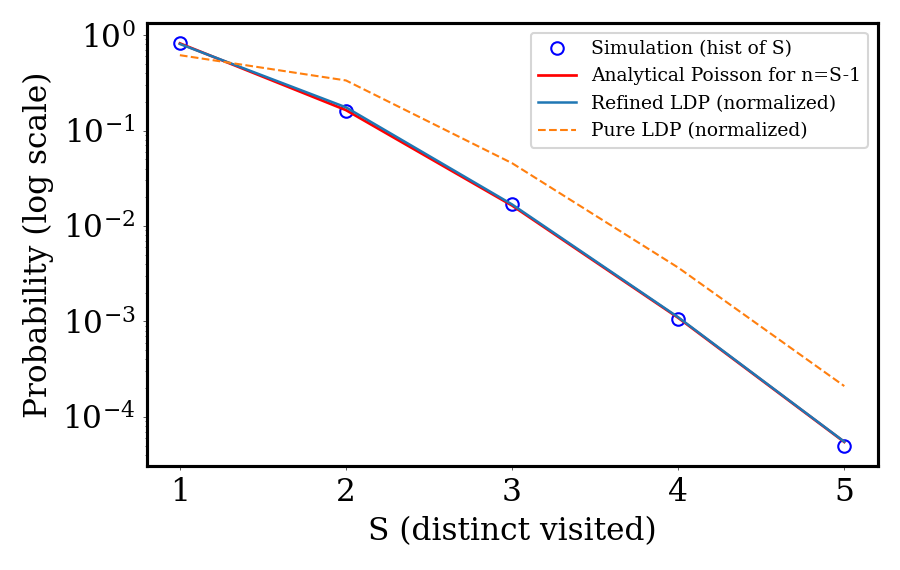

Simulated mean S: 1.199
Simulated var S: 0.200399
Total variation (sim vs analytical Poisson): 0.0022435027651820645


In [28]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import scipy.stats as stats
import math
import time

# -------------------------
# Graph preprocessing
# -------------------------
def preprocess_graph(G):
    nodes = np.array(list(G.nodes()), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    all_neighbors = []
    offsets = [0]
    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))
    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)
    return nodes, degrees, edges_flat, offsets

# -------------------------
# Numba simulation (returns counts per walker)
# -------------------------
@njit(parallel=True)
def simulate_distinct_counts(T, n_walkers, nodes, edges_flat, offsets, N, rate, start_node):
    counts = np.empty(n_walkers, dtype=np.int32)
    for i in prange(n_walkers):
        current = start_node  # fixed start; you can randomize outside numba if desired
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        t = 0.0
        while True:
            # exponential waiting time
            tau = np.random.exponential(1.0 / rate)
            if t + tau > T:
                break
            t += tau
            start, end = offsets[current], offsets[current + 1]
            if end > start:
                # choose a random neighbor uniformly
                idx = np.random.randint(end - start)
                current = edges_flat[start + idx]
                visited[current] = 1
        counts[i] = np.sum(visited)
    return counts

# -------------------------
# Rate & LDP functions
# -------------------------
def rate_function(r, lam):
    """I(r) = r log(r/lambda) - r + lambda, with safe handling"""
    if r <= 0:
        # limit r->0 is lambda (so e^{-t I(0)} = e^{-t*lambda} = P(N_t=0))
        return lam
    return r * math.log(r / lam) - r + lam

def Q_ldp(t, n, lam):
    # pure exponential LDP (may under/over-estimate prefactor)
    if n == 0:
        # limit r->0: I(0)=lambda
        return math.exp(-t * lam)
    r = n / t
    I = rate_function(r, lam)
    return math.exp(-t * I)

def Q_refined(t, n, lam):
    # refined saddle prefactor; handle n==0 exactly
    if n == 0:
        return math.exp(-t * lam)   # exact for n=0 (Poisson P(0))
    r = n / t
    I = rate_function(r, lam)
    pref = 1.0 / math.sqrt(2.0 * math.pi * r * t)
    return pref * math.exp(-t * I)

# -------------------------
# Parameters (change here)
# -------------------------
N = 1000                 # graph size
graph_type = 'complete'  # 'complete', 'er', 'ba', 'cycle'
n_walkers = 20000        # number of simulated walkers (reduce for speed)
rate = 2.0               # lambda
T_fixed = 0.1
start_node = 0           # starting node index for walkers (0..N-1)

# -------------------------
# Build graph
# -------------------------
if graph_type == 'complete':
    G = nx.complete_graph(N)
elif graph_type == 'er':
    p = 0.01
    G = nx.erdos_renyi_graph(N, p)
    if not nx.is_connected(G):
        G = max((G.subgraph(c) for c in nx.connected_components(G)), key=len)
        N = len(G)
elif graph_type == 'ba':
    m = 4
    G = nx.barabasi_albert_graph(N, m)
elif graph_type == 'cycle':
    G = nx.cycle_graph(N)
else:
    raise ValueError("unknown graph_type")

nodes, degrees, edges_flat, offsets = preprocess_graph(G)
N = len(nodes)  # update in case graph was reduced
print("Using graph with N =", N)

# -------------------------
# Run simulation
# -------------------------
start_time = time.time()
# simulate_distinct_counts is njit-parallel; compile/run
visited_counts = simulate_distinct_counts(T_fixed, n_walkers, nodes, edges_flat, offsets, N, rate, start_node)
print("Simulation done. time:", time.time() - start_time)

# -------------------------
# Build histogram of S (distinct visited)
# -------------------------
max_visits = int(np.max(visited_counts))
# We are interested in S (distinct nodes visited), and Q_t(n) is distribution of number of jumps n.
# For small T, number of jumps n is S-1 only if walker never revisits; here we compare S->n via n=S-1
v_vals = np.arange(1, max_visits + 1)
n_vals = v_vals - 1
hist = np.bincount(visited_counts, minlength=max_visits + 1)[1:]  # ignore 0
hist_prob = hist / np.sum(hist)

# -------------------------
# Analytical Poisson for number of jumps n (N_t)
# -------------------------
m = rate * T_fixed
P_analytical = stats.poisson.pmf(n_vals, mu=m)

# -------------------------
# LDP approximations (safe)
# -------------------------
Q_ldp_vals = np.array([Q_ldp(T_fixed, int(n), rate) for n in n_vals])
Q_ref_vals = np.array([Q_refined(T_fixed, int(n), rate) for n in n_vals])

# For plotting comparison of shapes, normalize approximations to sum 1 (so we compare pmf shapes)
Q_ldp_norm = Q_ldp_vals / np.sum(Q_ldp_vals)
Q_ref_norm = Q_ref_vals / np.sum(Q_ref_vals)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(6, 3.8), dpi=150)
plt.semilogy(v_vals, hist_prob, 'bo', mfc='none', label='Simulation')
plt.semilogy(v_vals, P_analytical, 'r-', lw=1.3, label='Analytical')
plt.semilogy(v_vals, Q_ref_norm, '-', lw=1.2, label='Refined LDP (normalized)')
plt.semilogy(v_vals, Q_ldp_norm, '--', lw=1.0, label='Pure LDP (normalized)')
plt.xlabel('S (distinct visited)')
plt.ylabel('Probability (log scale)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# -------------------------
# Print a few diagnostics
# -------------------------
print("Simulated mean S:", np.mean(visited_counts))
print("Simulated var S:", np.var(visited_counts))
# compare distributions (total variation distance between sim histogram and Poisson mapped from n=S-1)
tv = 0.5 * np.sum(np.abs(hist_prob - P_analytical))
print("Total variation (sim vs analytical Poisson):", tv)


degree of 0 node = 67
Using graph with N = 1000
Simulation done. time: 1.0306446552276611


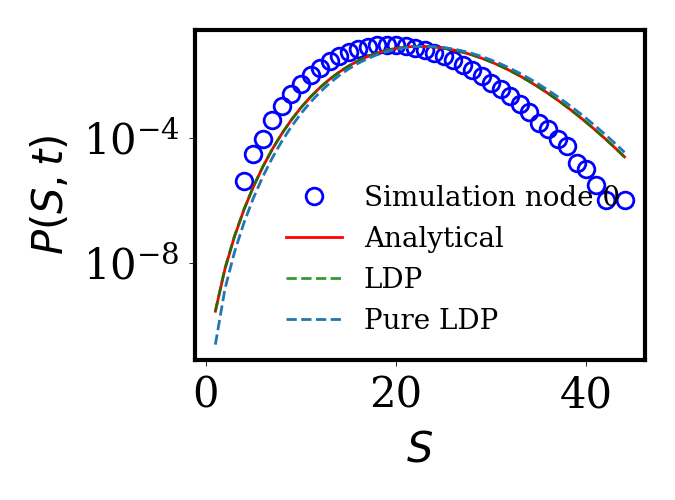

In [9]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import scipy.stats as stats
import math
import time

# -------------------------
# Graph preprocessing
# -------------------------
def preprocess_graph(G):
    nodes = np.array(list(G.nodes()), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    all_neighbors = []
    offsets = [0]
    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))
    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)
    return nodes, degrees, edges_flat, offsets

# -------------------------
# Numba simulation (returns counts per walker)
# -------------------------
@njit(parallel=True)
def simulate_distinct_counts(T, n_walkers, nodes, edges_flat, offsets, N, rate, start_node):
    counts = np.empty(n_walkers, dtype=np.int32)
    for i in prange(n_walkers):
        current = start_node  # fixed start; you can randomize outside numba if desired
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        t = 0.0
        while True:
            # exponential waiting time
            tau = np.random.exponential(1.0 / rate)
            if t + tau > T:
                break
            t += tau
            start, end = offsets[current], offsets[current + 1]
            if end > start:
                # choose a random neighbor uniformly
                idx = np.random.randint(end - start)
                current = edges_flat[start + idx]
                visited[current] = 1
        counts[i] = np.sum(visited)
    return counts

# -------------------------
# Rate & LDP functions
# -------------------------
def rate_function(r, lam):
    """I(r) = r log(r/lambda) - r + lambda, with safe handling"""
    if r <= 0:
        # limit r->0 is lambda (so e^{-t I(0)} = e^{-t*lambda} = P(N_t=0))
        return lam
    return r * math.log(r / lam) - r + lam

def Q_ldp(t, n, lam):
    # pure exponential LDP (may under/over-estimate prefactor)
    if n == 0:
        # limit r->0: I(0)=lambda
        return math.exp(-t * lam)
    r = n / t
    I = rate_function(r, lam)
    return math.exp(-t * I)

def Q_refined(t, n, lam):
    # refined saddle prefactor; handle n==0 exactly
    if n == 0:
        return math.exp(-t * lam)   # exact for n=0 (Poisson P(0))
    r = n / t
    I = rate_function(r, lam)
    pref = 1.0 / math.sqrt(2.0 * math.pi * r * t)
    return pref * math.exp(-t * I)

# -------------------------
# Parameters (change here)
# -------------------------
N = 1000                 # graph size
n_walkers = 1000000        # number of simulated walkers (reduce for speed)
rate = 2.0               # lambda
T_fixed = 11
start_node = 0           # starting node index for walkers (0..N-1)

p = 0.01
r,h=3,6
m=4
# Generate connected ER graph
while True:
    #G = nx.erdos_renyi_graph(N, p)
    G = nx.barabasi_albert_graph(N, m,seed=4)
    #G = nx.cycle_graph(N)
    #G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets = preprocess_graph(G)
N=len(G.nodes())
print("degree of 0 node =",G.degree(0))
print("Using graph with N =", N)
# -------------------------
# Run simulation
# -------------------------
start_time = time.time()
# simulate_distinct_counts is njit-parallel; compile/run
visited_counts = simulate_distinct_counts(T_fixed, n_walkers, nodes, edges_flat, offsets, N, rate, start_node)
print("Simulation done. time:", time.time() - start_time)
# -------------------------
# Build histogram of S (distinct visited)
# -------------------------

max_visits = int(np.max(visited_counts))
# We are interested in S (distinct nodes visited), and Q_t(n) is distribution of number of jumps n.
# For small T, number of jumps n is S-1 only if walker never revisits; here we compare S->n via n=S-1
v_vals = np.arange(1, max_visits + 1)
n_vals = v_vals - 1
hist = np.bincount(visited_counts, minlength=max_visits + 1)[1:]  # ignore 0
hist_prob = hist / np.sum(hist)

# -------------------------
# Analytical Poisson for number of jumps n (N_t)
# -------------------------
m = rate * T_fixed
P_analytical = stats.poisson.pmf(n_vals, mu=m)

# -------------------------
# LDP approximations (safe)
# -------------------------
Q_ldp_vals = np.array([Q_ldp(T_fixed, int(n), rate) for n in n_vals])
Q_ref_vals = np.array([Q_refined(T_fixed, int(n), rate) for n in n_vals])

# For plotting comparison of shapes, normalize approximations to sum 1 (so we compare pmf shapes)
Q_ldp_norm = Q_ldp_vals / np.sum(Q_ldp_vals)
Q_ref_norm = Q_ref_vals / np.sum(Q_ref_vals)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(3.375, 2.5),dpi=200)
plt.semilogy(v_vals, hist_prob, 'bo', mfc='none', label='Simulation node 0')
plt.semilogy(v_vals, P_analytical, 'r-', lw=1,alpha=1, label='Analytical')
plt.semilogy(v_vals, Q_ref_norm, 'g--', lw=1,alpha=0.8, label='LDP')
plt.semilogy(v_vals, Q_ldp_norm, '--', lw=1.0, label='Pure LDP')
plt.ylabel(r"$P(S, t)$")
plt.xlabel(r"$S$")
#plt.xticks([1,3,5,7,9])
#plt.yticks([1,0.01,0.0001,0.000001,0.00000001])
#plt.xlim(0.8,7.5)
#plt.ylim(0.00000001,3)
plt.legend(frameon=False,fontsize=10)
plt.tight_layout()
plt.show()


In [36]:
plt.savefig(f"./fig/complete_network_N_{N}_t_{T_fixed}_poisson_shifted111.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [59]:
plt.savefig(f"./fig/ER_N_1000_P_point01_t_point1_rate_2__walker_100000000_LDP.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [57]:
plt.savefig(f"./fig/BA_N_1000_m_4_t_point1_rate_2__walker_10000000000_LDP99.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [66]:
plt.savefig(f"./fig/BA_N_1000_m_4_t_point1_rate_2__walker_10000000000_LDP0_degree_67_99.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def I_T(x, A, C_A,C_Ap1):
    return -(C_Ap1/C_A)*t/N -(A+1)*(np.log(C_A * (np.math.gamma(A+1)**(1/A+1))*(t/N)/(A+1))+1))
P_(S,t)=np.exp(-N*I_T)
# Example parameters
A = 1.0            # e.g., Beta-like small-tau (A=1)
C_A = 6.0          # example constant used in your notes
x = np.linspace(0.01, 3.0, 400)

plt.figure(figsize=(6,3.6))
plt.plot(x, I_T(x, A, C_A), '-', lw=2)
plt.xlabel(r'$x = t/N$')
plt.ylabel(r'$I_T(x)$')
plt.title('Rate function $I_T(x)$')
plt.grid(True, ls=':')
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


In [67]:
print("degree of 0 node =",G.degree(99))

degree of 0 node = 12


Simulating... (this may use a few seconds)
Simulations done in 57.55 s (n_ensembles=2000000).
Saved data: Qt_data.npz
Saved: Qt_simulation_plot.png


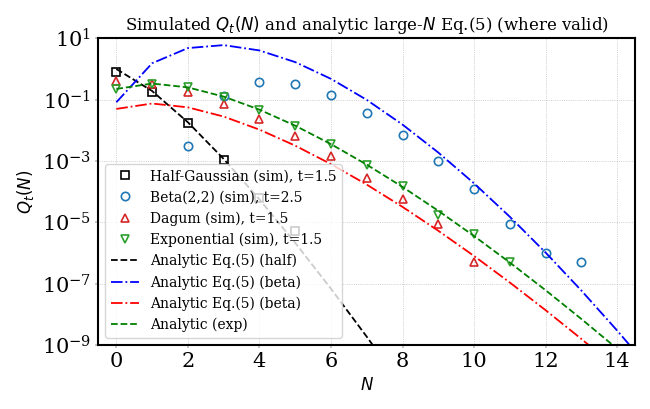

In [22]:
#!/usr/bin/env python3
# fast_Qt_simulation.py
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
import time

np.random.seed(0)

# ---------- distribution samplers (vectorized batches) ----------
def sample_exponential_batch(size):
    # Exponential waiting time with mean = 1
    return np.random.exponential(scale=1.0, size=size)

def sample_half_gaussian_batch(shape):
    # pdf: (2/(5*pi)) * exp(-t^2/(25*pi)) for t>=0
    # Equivalent to a half-normal with moments matched as in user's pdf.
    # We can sample from normal with sigma chosen such that mean matches computed value.
    # But here we draw via inverse CDF sampling using the known form:
    # Since user's pdf is normalized, sampling by acceptance of normal is straightforward.
    # Simpler: draw normal with sigma = sqrt(25*pi/2) then take abs (half-normal).
    sigma = np.sqrt(25.0 * np.pi / 2.0)
    return np.abs(np.random.normal(loc=0.0, scale=sigma, size=shape))

def sample_beta_2_2_batch(shape):
    return np.random.beta(2.0, 2.0, size=shape)

def sample_dagum_batch(shape):
    # psi(t)=1/(1+t)^2, CDF = t/(1+t), inverse u -> t = u/(1-u)
    u = np.random.rand(*shape)
    return u / (1.0 - u)

# ---------- vectorized renewal simulation ----------

def simulate_Qt_vectorized(sample_batch_func, t_measure, n_ensembles=200_000, max_events=200):
    """
    Vectorized: draw an (n_ensembles x max_events) array of waiting times,
    compute cumulative sums along axis=1, count how many increments are < t_measure.
    Returns unique_N, pmf array.
    """
    # Draw block of waiting times
    W = sample_batch_func((n_ensembles, max_events))
    # cumulative sums
    S = np.cumsum(W, axis=1)
    # count events strictly before t_measure
    # For each row, the number of events N is number of S < t_measure
    Ncounts = np.sum(S < t_measure, axis=1)
    # histogram
    uniq, cnts = np.unique(Ncounts, return_counts=True)
    pmf = cnts / n_ensembles
    return uniq, pmf

# ---------- analytic asymptotic Eq.(5) ----------

def Q_analytic(N_array, t, A, C_A, C_Ap1):
    # user-supplied formula:
    # { [C_A Gamma(A+1)]^{1/(A+1)} t }^{N(A+1)} / Gamma[N(A+1)+1] * exp((C_{A+1}/C_A) t)
    base = ( (C_A * gamma(A+1.0)) ** (1.0/(A+1.0)) * t )
    exp_term = np.exp((C_Ap1 / C_A) * t)
    numer = base ** (N_array * (A+1.0))
    denom = gamma(N_array * (A+1.0) + 1.0)
    return numer / denom * exp_term

# ---------- main run ----------

if __name__ == '__main__':
    t0 = time.time()

    # measurement times per caption
    t_half = 1.5
    t_beta = 2.5
    t_dagum = 1.5
    t_exp = 1.5 
    
    n_ensembles = 2000000   # adjust to taste; large but still fast due to vectorization
    max_events = 120        # should exceed typical N at given t

    print("Simulating... (this may use a few seconds)")
    uh, qh = simulate_Qt_vectorized(sample_half_gaussian_batch, t_half, n_ensembles=n_ensembles, max_events=max_events)
    ub, qb = simulate_Qt_vectorized(sample_beta_2_2_batch,      t_beta, n_ensembles=n_ensembles, max_events=max_events)
    ud, qd = simulate_Qt_vectorized(sample_dagum_batch,       t_dagum, n_ensembles=n_ensembles, max_events=max_events)
    ue, qe = simulate_Qt_vectorized(sample_exponential_batch,  t_exp, n_ensembles=n_ensembles, max_events=max_events)
    
    t1 = time.time()
    print(f"Simulations done in {t1 - t0:.2f} s (n_ensembles={n_ensembles}).")
    C0_hg = 2.0 / (5.0 * np.pi)
    # analytic constants we determined:
    params = {
        'half':  {'A': 0, 'C_A': C0_hg, 'C_Ap1': 0, 't': t_half},
        'beta':  {'A': 1.0, 'C_A': 6, 'C_Ap1': -6,  't': t_beta},
        'dagum': {'A': 0, 'C_A': 1.0, 'C_Ap1': -2, 't':t_dagum},
        'exp':   {'A': 0, 'C_A': 1.0, 'C_Ap1': -1.0, 't': t_exp},
        # For Dagum: analytic Eq.(5) NOT APPLICABLE (log correction); we do not compute analytic curve.
    }

    Nmax = max(int(np.max(uh)), int(np.max(ub)), int(np.max(ud)), 20)
    Ngrid = np.arange(0, Nmax + 6)

    Qh_analytic = Q_analytic(Ngrid, **params['half'])
    Qb_analytic = Q_analytic(Ngrid, **params['beta'])
    Qd_analytic = Q_analytic(Ngrid, **params['dagum'])
    Qe_analytic = Q_analytic(Ngrid, **params['exp'])
    # no analytic for dagum (set to None)
    # ---------- Save data ----------
    np.savez(
        "Qt_data.npz",
        Ngrid=Ngrid,
        uh=uh, qh=qh,
        ub=ub, qb=qb,
        ud=ud, qd=qd,
        ue=ue, qe=qe,
        Qh_analytic=Qh_analytic,
        Qb_analytic=Qb_analytic,
        Qd_analytic=Qd_analytic,
        Qe_analytic=Qe_analytic
        )
    print("Saved data: Qt_data.npz")

    # ---------- Plot ----------
    plt.figure(figsize=(6.5,4.1))
    ax = plt.gca()
    ax.semilogy(uh, qh, marker='s', linestyle='none', markeredgewidth=1.2, markerfacecolor='none',
                markersize=6, color='k', label='Half-Gaussian (sim), t=1.5')
    ax.semilogy(ub, qb, marker='o', linestyle='none', markeredgewidth=1.2, markerfacecolor='none',
                markersize=6, color='tab:blue', label='Beta(2,2) (sim), t=2.5')
    ax.semilogy(ud, qd, marker='^', linestyle='none', markeredgewidth=1.2, markerfacecolor='none',
                markersize=6, color='tab:red', label='Dagum (sim), t=1.5')
    ax.semilogy(ue, qe, marker='v', linestyle='none', markeredgewidth=1.2,
            markerfacecolor='none', markersize=6, color='tab:green',
            label='Exponential (sim), t=1.5')
    ax.semilogy(Ngrid, Qh_analytic, 'k--', linewidth=1.3, label='Analytic Eq.(5) (half)')
    ax.semilogy(Ngrid, Qb_analytic, 'b-.', linewidth=1.3, label='Analytic Eq.(5) (beta)')
    ax.semilogy(Ngrid, Qd_analytic, 'r-.', linewidth=1.3, label='Analytic Eq.(5) (beta)')
    ax.semilogy(Ngrid, Qe_analytic, 'g--', linewidth=1.3, label='Analytic (exp)')
    # analytic for dagum not plotted

    ax.set_xlim(-0.5, 14.5)
    ax.set_ylim(1e-9, 10.0)
    ax.set_xlabel(r'$N$', fontsize=12)
    ax.set_ylabel(r'$Q_t(N)$', fontsize=12)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)
    ax.legend(fontsize=10)
    plt.title('Simulated $Q_t(N)$ and analytic large-$N$ Eq.(5) (where valid)')
    plt.tight_layout()
    plt.savefig("Qt_simulation_plot.png", dpi=200)
    print("Saved: Qt_simulation_plot.png")

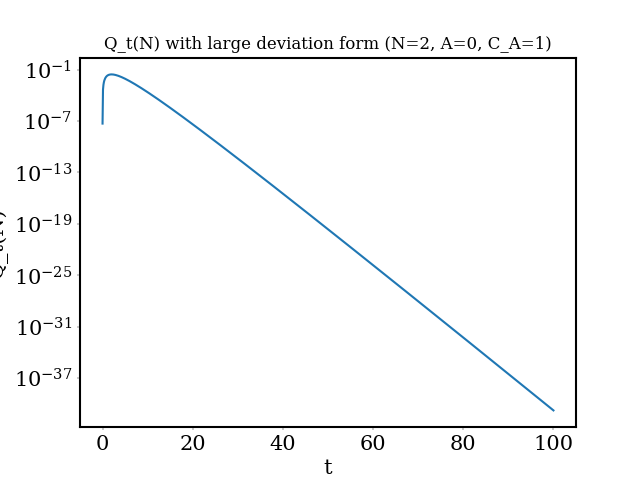

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps

def rate_function(t, N, A, C_A,C_Ap1):
    """Compute the rate function I_t(t/N)."""
    x = t / N
    prefactor = (A + 1)
    term1 = -np.log((np.exp(1) * (C_A * np.math.gamma(A + 1))**(1/(A+1))*x)/(prefactor))
    term2 = - (C_Ap1) *x/ (prefactor * C_A)
    I = prefactor * (term1 + term2)
    return I

def Qt_large_dev(t_vals, N, A, C_A,C_Ap1):
    """Compute Qt(N) in large deviation form with normalization."""
    I_vals = rate_function(t_vals, N, A, C_A,C_Ap1)
    Qt= np.exp(-N * I_vals)

    return Qt
def Qt_large_dev_ref(t_vals, N, A, C_A,C_Ap1):
    """Compute Qt(N) in large deviation form with normalization."""
    I_vals = rate_function(t_vals, N, A, C_A,C_Ap1)
    prefactor=1/(np.sqrt(2*np.pi*N*(A+1)))
    Qt= prefactor*np.exp(-N * I_vals)

    return Qt
# Parameters
N = 2
A = 0
C_A = 1
C_Ap1=-1
# Time range
t_vals = np.linspace(.001, 100, 1000)

# Compute Qt(N)
Q_ldp_vals = np.array([Qt_large_dev(T, N,A ,C_A,C_Ap1) for T in t_vals])
Q_ldp_norm = Q_ldp_vals / np.sum(Q_ldp_vals)

Q_ldp_vals_ref = np.array([Qt_large_dev_ref(T, N,A ,C_A,C_Ap1) for T in t_vals])
Q_ldp_norm_ref = Q_ldp_vals / np.sum(Q_ldp_vals_ref)
# Plot
plt.figure()
plt.plot(t_vals, Q_ldp_norm)
plt.xlabel('t')
plt.ylabel('Q_t(N)')
plt.title(f'Q_t(N) with large deviation form (N={N}, A={A}, C_A={C_A})')
plt.yscale('log')  # Optional: log scale for clarity
plt.show()


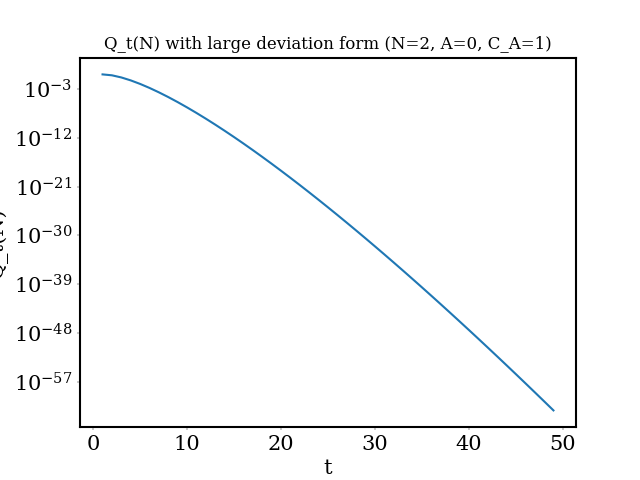

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps

def rate_function(t, N, A, C_A,C_Ap1):
    """Compute the rate function I_t(t/N)."""
    x = t / N
    prefactor = (A + 1)
    term1 = -np.log((np.exp(1) * (C_A * np.math.gamma(A + 1))**(1/(A+1))*x)/(prefactor))
    term2 = - (C_Ap1) *x/ (prefactor * C_A)
    I = prefactor * (term1 + term2)
    return I

def Qt_large_dev(t_vals, N, A, C_A,C_Ap1):
    """Compute Qt(N) in large deviation form with normalization."""
    I_vals = rate_function(t_vals, N, A, C_A,C_Ap1)
    Qt= np.exp(-N * I_vals)

    return Qt

# Parameters
N = 2
A = 0
C_A = 1
C_Ap1=-1
# Time range
t_vals = np.linspace(.001, 100, 1000)
T=1
n_vals=np.arange(1,50)
# Compute Qt(N)
Q_ldp_vals = np.array([Qt_large_dev(T, n,A ,C_A,C_Ap1) for n in n_vals])
Q_ldp_norm = Q_ldp_vals / np.sum(Q_ldp_vals)
# Plot
plt.figure()
plt.plot(n_vals, Q_ldp_norm)
plt.xlabel('t')
plt.ylabel('Q_t(N)')
plt.title(f'Q_t(N) with large deviation form (N={N}, A={A}, C_A={C_A})')
plt.yscale('log')  # Optional: log scale for clarity
plt.show()

In [48]:
n_vals

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

degree of 0 node = 67
Using graph with N = 1000
Simulation done. time: 0.6295166015625


/tmp/ipykernel_24290/3764609927.py:73: RuntimeWarning: divide by zero encountered in double_scalars
  prefactor=1/(np.sqrt(2*np.pi*N*(A+1)))


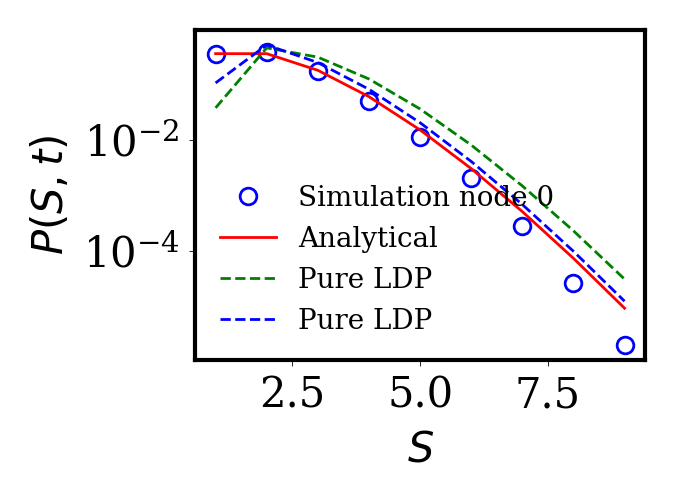

In [94]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import scipy.stats as stats
import math
import time

# -------------------------
# Graph preprocessing
# -------------------------
def preprocess_graph(G):
    nodes = np.array(list(G.nodes()), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    all_neighbors = []
    offsets = [0]
    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))
    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)
    return nodes, degrees, edges_flat, offsets

# -------------------------
# Numba simulation (returns counts per walker)
# -------------------------
@njit(parallel=True)
def simulate_distinct_counts(T, n_walkers, nodes, edges_flat, offsets, N, rate, start_node):
    counts = np.empty(n_walkers, dtype=np.int32)
    for i in prange(n_walkers):
        current = start_node  # fixed start; you can randomize outside numba if desired
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        t = 0.0
        while True:
            # exponential waiting time
            tau = np.random.exponential(1.0 / rate)
            if t + tau > T:
                break
            t += tau
            start, end = offsets[current], offsets[current + 1]
            if end > start:
                # choose a random neighbor uniformly
                idx = np.random.randint(end - start)
                current = edges_flat[start + idx]
                visited[current] = 1
        counts[i] = np.sum(visited)
    return counts

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps

def rate_function(t, N, A, C_A,C_Ap1):
    """Compute the rate function I_t(t/N)."""
    x = t / N
    prefactor = (A + 1)
    term1 = -np.log((np.exp(1) * (C_A * np.math.gamma(A + 1))**(1/(A+1))*x)/(prefactor))
    term2 = - (C_Ap1) *x/ (prefactor * C_A)
    I = prefactor * (term1 + term2)
    return I

def Qt_large_dev(t_vals, N, A, C_A,C_Ap1):
    if N==0:
        Qt=math.exp(-t * C_A)
    else:
        I_vals = rate_function(t_vals, N, A, C_A,C_Ap1)
        Qt= np.exp(-N * I_vals)

    return Qt
def Qt_large_dev_ref(t_vals, N, A, C_A,C_Ap1):
    prefactor=1/(np.sqrt(2*np.pi*N*(A+1)))
    if N==0:
        Qt=math.exp(-t * C_A)
    else:
        I_vals = rate_function(t_vals, N, A, C_A,C_Ap1)
        
        Qt= prefactor*np.exp(-N * I_vals)

    return Qt
# -------------------------
# Parameters (change here)
# -------------------------
N = 1000                 # graph size
n_walkers = 1000000        # number of simulated walkers (reduce for speed)
rate = 1.0               # lambda
T_fixed = 1
start_node = 0           # starting node index for walkers (0..N-1)
A = 0
C_A = 1
C_Ap1=-1
p = 0.01
r,h=3,6
m=4
# Generate connected ER graph
while True:
    #G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,seed=4)
    #G = nx.cycle_graph(N)
    #G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets = preprocess_graph(G)
N=len(G.nodes())
print("degree of 0 node =",G.degree(0))
print("Using graph with N =", N)
# -------------------------
# Run simulation
# -------------------------
start_time = time.time()
# simulate_distinct_counts is njit-parallel; compile/run
visited_counts = simulate_distinct_counts(T_fixed, n_walkers, nodes, edges_flat, offsets, N, rate, start_node)
print("Simulation done. time:", time.time() - start_time)
# -------------------------
# Build histogram of S (distinct visited)
# -------------------------

max_visits = int(np.max(visited_counts))
#max_visits = 100
# We are interested in S (distinct nodes visited), and Q_t(n) is distribution of number of jumps n.
# For small T, number of jumps n is S-1 only if walker never revisits; here we compare S->n via n=S-1
v_vals = np.arange(1, max_visits + 1)
n_vals = v_vals - 1
hist = np.bincount(visited_counts, minlength=max_visits + 1)[1:]  # ignore 0
hist_prob = hist / np.sum(hist)

# -------------------------
# Analytical Poisson for number of jumps n (N_t)
# -------------------------
m = rate * T_fixed
P_analytical = stats.poisson.pmf(n_vals, mu=m)

# -------------------------
# LDP approximations (safe)
# -------------------------
Q_ldp_vals = np.array([Qt_large_dev(T_fixed, n,A ,C_A,C_Ap1) for n in n_vals])
Q_ldp_norm = Q_ldp_vals / np.sum(Q_ldp_vals)


Q_ldp_vals_ref = np.array([Qt_large_dev_ref(T_fixed, n,A ,C_A,C_Ap1) for n in n_vals])
Q_ldp_norm_ref = Q_ldp_vals_ref / np.sum(Q_ldp_vals_ref)
# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(3.375, 2.5),dpi=200)
plt.semilogy(v_vals, hist_prob, 'bo', mfc='none', label='Simulation node 0')
plt.semilogy(v_vals, P_analytical, 'r-', lw=1,alpha=1, label='Analytical')
plt.semilogy(v_vals, Q_ldp_norm, 'g--', lw=1.0, label='Pure LDP')
plt.semilogy(v_vals, Q_ldp_norm_ref, 'b--', lw=1.0, label='Pure LDP')
plt.ylabel(r"$P(S, t)$")
plt.xlabel(r"$S$")
#plt.xticks([1,3,5,7,9])
#plt.yticks([1,0.01,0.0001,0.000001,0.00000001])
#plt.xlim(0.8,7.5)
#plt.ylim(0.00000001,3)
plt.legend(frameon=False,fontsize=10)
plt.tight_layout()
plt.show()


degree of 0 node = 999
Using graph with N = 1000
Simulation done. time: 0.6219043731689453


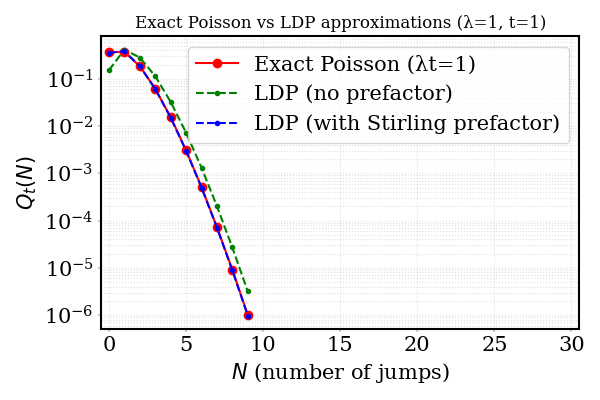

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy import stats
import math
import networkx as nx
from numba import njit, prange
import time

# -------------------------
# Graph preprocessing
# -------------------------
def preprocess_graph(G):
    nodes = np.array(list(G.nodes()), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    all_neighbors = []
    offsets = [0]
    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))
    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)
    return nodes, degrees, edges_flat, offsets

# -------------------------
# Numba simulation (returns counts per walker)
# -------------------------
@njit(parallel=True)
def simulate_distinct_counts(T, n_walkers, nodes, edges_flat, offsets, N, rate, start_node):
    counts = np.empty(n_walkers, dtype=np.int32)
    for i in prange(n_walkers):
        current = start_node  # fixed start; you can randomize outside numba if desired
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        t = 0.0
        while True:
            # exponential waiting time
            tau = np.random.exponential(1.0 / rate)
            if t + tau > T:
                break
            t += tau
            start, end = offsets[current], offsets[current + 1]
            if end > start:
                # choose a random neighbor uniformly
                idx = np.random.randint(end - start)
                current = edges_flat[start + idx]
                visited[current] = 1
        counts[i] = np.sum(visited)
    return counts

# -------------------------
# Rate / LDP (scalar-safe)
# -------------------------
def rate_function_scalar(t, N, A, C_A, C_Ap1):
    """Compute scalar rate function I_t(t/N). Assumes N>0."""
    x = float(t) / float(N)
    prefactor = (A + 1)
    K = (C_A * math.gamma(A + 1))**(1.0 / (A + 1))
    # term1 corresponds to -log( e * K * (A+1) * t / N )
    term1 = -math.log( (math.e * K *  x) /prefactor )  # algebra arranged as before
    # term2 is - (C_{A+1}) * x / (prefactor * C_A)
    term2 = - (C_Ap1) * x / (prefactor * C_A)
    I = prefactor * (term1 + term2)
    return I
def Qt_large_dev_logs(t, N_array, A, C_A, C_Ap1, with_prefactor=False):
    """
    Compute Q_t(N) for N_array (array-like integers) using log normalization.
    Returns array of normalized probabilities.
    """
    t = float(t)
    N_array = np.asarray(N_array, dtype=np.int64)
    logQ = np.full(N_array.shape, -np.inf, dtype=float)

    # handle N=0 explicitly if present (exponential waiting: Q_t(0) = exp(-C_A * t))
    # more generally for small N you should use exact formula
    for i, N in enumerate(N_array):
        if N == 0:
            # For exponential with C_A = lambda, Q_t(0) = exp(-lambda * t)
            logQ[i] = -C_A * t
        else:
            I = rate_function_scalar(t, N, A, C_A, C_Ap1)
            logQ[i] = -N * I
            if with_prefactor:
                # add log of prefactor 1/sqrt(2*pi*N*(A+1))
                logQ[i] += -0.5 * math.log(2.0 * math.pi * N * (A + 1))

    # normalize in log space
    logQ_norm = logQ - logsumexp(logQ)
    return np.exp(logQ_norm), logQ, logQ_norm
# -------------------------
# Parameters (change here)
# -------------------------
N = 1000                 # graph size
n_walkers = 1000000        # number of simulated walkers (reduce for speed)
rate = 1.0               # lambda
T_fixed = 1
start_node = 0           # starting node index for walkers (0..N-1)
A = 0
C_A = rate       # C_A = lambda
C_Ap1 = -rate**2 # C_{A+1} = -lambda^2
p = 0.01
r,h=3,6
m=4
# Generate connected ER graph
while True:
    #G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,seed=4)
    #G = nx.cycle_graph(N)
    G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets = preprocess_graph(G)
N=len(G.nodes())
print("degree of 0 node =",G.degree(0))
print("Using graph with N =", N)
# -------------------------
# Run simulation
# -------------------------
start_time = time.time()
# simulate_distinct_counts is njit-parallel; compile/run
visited_counts = simulate_distinct_counts(T_fixed, n_walkers, nodes, edges_flat, offsets, N, rate, start_node)
print("Simulation done. time:", time.time() - start_time)
# -------------------------
# Build histogram of S (distinct visited)
# -------------------------

max_visits = int(np.max(visited_counts))
# We are interested in S (distinct nodes visited), and Q_t(n) is distribution of number of jumps n.
# For small T, number of jumps n is S-1 only if walker never revisits; here we compare S->n via n=S-1
v_vals = np.arange(1, max_visits + 1)
n_vals = v_vals - 1
hist = np.bincount(visited_counts, minlength=max_visits + 1)[1:]  # ignore 0
hist_prob = hist / np.sum(hist)

# -------------------------
# Analytical Poisson for number of jumps n (N_t)
# -------------------------
P_analytical = stats.poisson.pmf(n_vals, mu=rate * T_fixed)

# -------------------------
# LDP predictions (log-stable)
# -------------------------
Q_ldp, logQ_raw, logQ_norm = Qt_large_dev_logs(T_fixed, n_vals, A, C_A, C_Ap1, with_prefactor=False)
Q_ldp_pref, _, _ = Qt_large_dev_logs(T_fixed, n_vals, A, C_A, C_Ap1, with_prefactor=True)

# -------------------------
# Plot comparison
# -------------------------
plt.figure(figsize=(6,4))
plt.semilogy(n_vals, P_analytical, 'ro-', label='Exact Poisson (λt=1)', markersize=6)
plt.semilogy(n_vals, Q_ldp, 'g.--', label='LDP (no prefactor)', markersize=6)
plt.semilogy(n_vals, Q_ldp_pref, 'b.--', label='LDP (with Stirling prefactor)', markersize=6)
plt.xlabel(r'$N$ (number of jumps)')
plt.ylabel(r'$Q_t(N)$')
plt.title('Exact Poisson vs LDP approximations (λ=1, t=1)')
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.4)
plt.xlim(-0.5, n_max + 0.5)
plt.tight_layout()
plt.show()


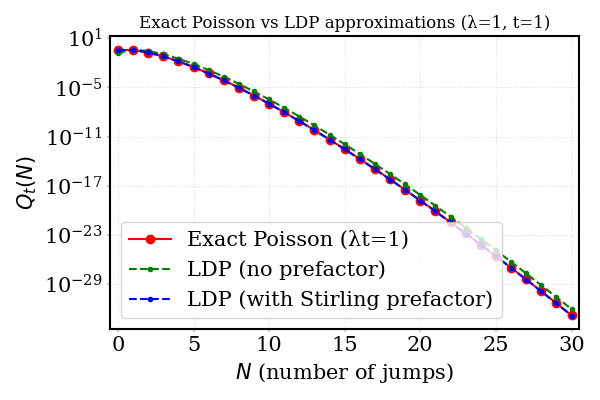

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy import stats
import math

# -------------------------
# Rate / LDP (scalar-safe)
# -------------------------
def rate_function_scalar(t, N, A, C_A, C_Ap1):
    """Compute scalar rate function I_t(t/N). Assumes N>0."""
    x = float(t) / float(N)
    prefactor = (A + 1)
    K = (C_A * math.gamma(A + 1))**(1.0 / (A + 1))
    # term1 corresponds to -log( e * K * (A+1) * t / N )
    term1 = -math.log( (math.e * K *  x) /prefactor )  # algebra arranged as before
    # term2 is - (C_{A+1}) * x / (prefactor * C_A)
    term2 = - (C_Ap1) * x / (prefactor * C_A)
    I = prefactor * (term1 + term2)
    return I
def Qt_large_dev_logs(t, N_array, A, C_A, C_Ap1, with_prefactor=False):
    """
    Compute Q_t(N) for N_array (array-like integers) using log normalization.
    Returns array of normalized probabilities.
    """
    t = float(t)
    N_array = np.asarray(N_array, dtype=np.int64)
    logQ = np.full(N_array.shape, -np.inf, dtype=float)

    # handle N=0 explicitly if present (exponential waiting: Q_t(0) = exp(-C_A * t))
    # more generally for small N you should use exact formula
    for i, N in enumerate(N_array):
        if N == 0:
            # For exponential with C_A = lambda, Q_t(0) = exp(-lambda * t)
            logQ[i] = -C_A * t
        else:
            I = rate_function_scalar(t, N, A, C_A, C_Ap1)
            logQ[i] = -N * I
            if with_prefactor:
                # add log of prefactor 1/sqrt(2*pi*N*(A+1))
                logQ[i] += -0.5 * math.log(2.0 * math.pi * N * (A + 1))

    # normalize in log space
    logQ_norm = logQ - logsumexp(logQ)
    return np.exp(logQ_norm), logQ, logQ_norm

# -------------------------
# Parameters
# -------------------------
rate = 1.0        # lambda for exponential psi(t) = lambda e^{-lambda t}
T_fixed = 1.0
A = 0
C_A = rate       # C_A = lambda
C_Ap1 = -rate**2 # C_{A+1} = -lambda^2

# n range (number of jumps)
n_max = 30
n_vals = np.arange(0, n_max + 1)   # include N=0
# exact Poisson for exponential waiting times
P_poisson = stats.poisson.pmf(n_vals, mu=rate * T_fixed)

# -------------------------
# LDP predictions (log-stable)
# -------------------------
Q_ldp, logQ_raw, logQ_norm = Qt_large_dev_logs(T_fixed, n_vals, A, C_A, C_Ap1, with_prefactor=False)
Q_ldp_pref, _, _ = Qt_large_dev_logs(T_fixed, n_vals, A, C_A, C_Ap1, with_prefactor=True)

# -------------------------
# Plot comparison
# -------------------------
plt.figure(figsize=(6,4))
plt.semilogy(n_vals, P_poisson, 'ro-', label='Exact Poisson (λt=1)', markersize=6)
plt.semilogy(n_vals, Q_ldp, 'g.--', label='LDP (no prefactor)', markersize=6)
plt.semilogy(n_vals, Q_ldp_pref, 'b.--', label='LDP (with Stirling prefactor)', markersize=6)
plt.xlabel(r'$N$ (number of jumps)')
plt.ylabel(r'$Q_t(N)$')
plt.title('Exact Poisson vs LDP approximations (λ=1, t=1)')
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.4)
plt.xlim(-0.5, n_max + 0.5)
plt.tight_layout()
plt.show()


In [27]:
from numba import njit, prange
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy import stats
import math
import networkx as nx
from numba import njit, prange
import time

# -------------------------
# Graph preprocessing
# -------------------------
def preprocess_graph(G):
    nodes = np.array(list(G.nodes()), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    all_neighbors = []
    offsets = [0]
    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))
    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)
    return nodes, degrees, edges_flat, offsets
@njit(parallel=True)
def simulate_distinct_counts(T, n_walkers, nodes, edges_flat, offsets, N, dist_type, start_node,rate):
    counts = np.empty(n_walkers, dtype=np.int32)

    for i in prange(n_walkers):
        current = start_node
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        t = 0.0

        while True:
            # Draw waiting time τ from chosen distribution ψ(τ)
            if dist_type == 0:
                tau = np.random.exponential(1.0 / rate)  # exponential with mean 1
            elif dist_type == 1:
                # Half-Gaussian: take absolute value of Gaussian(0, σ²)
                sigma = np.sqrt(25 * np.pi / 2.0)
                tau = abs(np.random.normal(0.0, sigma))
            elif dist_type == 2:
                # Beta(2,2) scaled to τ ∈ [0,1]
                tau = np.random.beta(2.0, 2.0)
            elif dist_type == 3:
                # Dagum-like ψ(τ) ∝ 1/(1+τ)^2
                # equivalent to τ = 1/u - 1 where u ~ Uniform(0,1)
                u = np.random.random()
                tau = u /(1- u) 
            else:
                tau = np.random.exponential(1.0)

            if t + tau > T:
                break

            t += tau
            start, end = offsets[current], offsets[current + 1]
            if end > start:
                idx = np.random.randint(end - start)
                current = edges_flat[start + idx]
                visited[current] = 1

        counts[i] = np.sum(visited)

    return counts
# -------------------------
# Rate / LDP (scalar-safe)
# -------------------------
def rate_function_scalar(t, N, A, C_A, C_Ap1):
    """Compute scalar rate function I_t(t/N). Assumes N>0."""
    x = float(t) / float(N)
    K = (C_A * math.gamma(A + 1))**(1.0 / (A + 1))
    # term1 corresponds to -log( e * K * t / N(A+1) )
    term1 = -math.log( (math.e * K *  x) /(A+1))
    # term2 is - (C_{A+1}) * x / (prefactor * C_A)
    term2 = - (C_Ap1) * x / ((A+1) * C_A)
    I = (A+1) * (term1 + term2)
    return I
def Qt_large_dev_logs(t, N_array, A, C_A, C_Ap1, with_prefactor=False):
    """
    Compute Q_t(N) for N_array (array-like integers) using log normalization.
    Returns array of normalized probabilities.
    """
    t = float(t)
    N_array = np.asarray(N_array, dtype=np.int64)
    logQ = np.full(N_array.shape, -np.inf, dtype=float)

    # handle N=0 explicitly if present (exponential waiting: Q_t(0) = exp(-C_A * t))
    # more generally for small N you should use exact formula
    for i, N in enumerate(N_array):
        if N == 0:
            # For exponential with C_A = lambda, Q_t(0) = exp(-lambda * t)
            logQ[i] = -C_A * t
        else:
            I = rate_function_scalar(t, N, A, C_A, C_Ap1)
            logQ[i] = -N * I
            if with_prefactor:
                # add log of prefactor 1/sqrt(2*pi*N*(A+1))
                logQ[i] += -0.5 * math.log(2.0 * math.pi * N * (A + 1))

    # normalize in log space
    logQ_norm = logQ - logsumexp(logQ)
    return np.exp(logQ_norm), logQ, logQ_norm

def Qt_large_dev(t, N_array, A, C_A, C_Ap1, with_prefactor=False):
    """
    Non-log version of large-deviation approximation for Q_t(N):
        Q_t(N) ~ exp(-N I_t(t/N)) * prefactor
    After computing for all N_array, probabilities are normalized normally.
    """
    t = float(t)
    N_array = np.asarray(N_array, dtype=np.int64)
    Q = np.zeros_like(N_array, dtype=float)

    for i, N in enumerate(N_array):

        # N = 0 special case (exponential waiting example)
        if N == 0:
            Q[i] = math.exp(-C_A * t)
            continue

        I = rate_function_scalar(t, N, A, C_A, C_Ap1)

        # main large deviation term
        q_val = math.exp(-N * I)

        # prefactor (optional)
        if with_prefactor:
            #pref = 1.0 / math.sqrt(2.0 * math.pi * N * (A + 1))
            pref = 1.0 / math.sqrt(N * (A + 1))
            q_val *= pref

        Q[i] = q_val

    # normalize in normal space
    total = np.sum(Q)
    if total > 0:
        Q_norm = Q / total
    else:
        Q_norm = Q

    return Q_norm, Q


degree of 0 node = 999
Using graph with N = 1000
Simulation done. time: 4.082576513290405


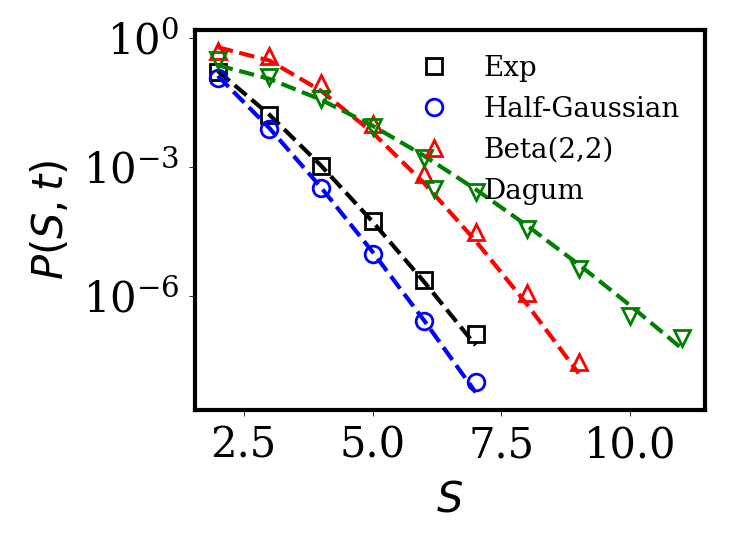

In [37]:
# -------------------------
# Parameters (change here)
# -------------------------
N = 1000                 # graph size
n_walkers = 1000000        # number of simulated walkers (reduce for speed)
rate = 2.0               # lambda
T_fixed = 1
start_node = 0           # starting node index for walkers (0..N-1)
p = 0.01
r,h=3,6
m=4
# Generate connected ER graph
while True:
    #G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,seed=4)
    #G = nx.cycle_graph(N)
    G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets = preprocess_graph(G)
N=len(G.nodes())
print("degree of 0 node =",G.degree(0))
print("Using graph with N =", N)
# -------------------------
# Run simulation
# -------------------------
start_time = time.time()
C0_hg = 2.0 / (5.0 * np.pi)
dist_types = [0,1, 2, 3]
T_values = [.1,1., 1.0, 1]  # as in your figure
labels = ["Exp", "Half-Gaussian", "Beta(2,2)", "Dagum"]
col=["k--","b--","r--","g--"]
As=[0,0,1,0]
C_As=[rate,C0_hg,6,1]
C_Ap1s=[-(rate**2),0,-6,-2]
scol=["k","b","r","g"]
simcol=["s","o","^","v"]
plt.figure(figsize=(3.675, 2.75),dpi=200)
for dist_type, T, label,A,C_A,C_Ap1 in zip(dist_types, T_values, labels,As,C_As,C_Ap1s):
     
    counts = simulate_distinct_counts(
        T=T,
        n_walkers=100000000,
        nodes=nodes,
        edges_flat=edges_flat,
        offsets=offsets,
        N=N,
        dist_type=dist_type,
        start_node=0,
        rate=rate
    )
    max_visits = int(np.max(counts))
    v_vals = np.arange(1, max_visits + 1)
    hist = np.bincount(counts, minlength=max_visits + 1)[1:]  # ignore 0
    hist_prob = hist / np.sum(hist)
    Q_ldp_pref, _, _ = Qt_large_dev_logs(T, v_vals-1, A, C_A, C_Ap1, with_prefactor=True)
    plt.semilogy(v_vals[1:], hist_prob[1:],color=scol[dist_type],linestyle='none',marker=simcol[dist_type],mfc='none', label=label)
    plt.semilogy(v_vals[1:], Q_ldp_pref[1:],  col[dist_type], markersize=6)
plt.xlabel(r"$S$")
plt.ylabel(r"$P(S,t)$")
print("Simulation done. time:", time.time() - start_time)
#plt.xlim(-0.5, 14.5)
#plt.ylim(1e-9, 10.0)
plt.legend(frameon=False,fontsize=10)
plt.tight_layout()
plt.show()


degree of 0 node = 92
Using graph with N = 1000
Saved: ERD_Qt_dist_n_walkers_1000000Exp.csv
Saved: ERD_Qt_dist_n_walkers_1000000Half-Gaussian.csv
Saved: ERD_Qt_dist_n_walkers_1000000Beta(2,2).csv
Saved: ERD_Qt_dist_n_walkers_1000000Dagum.csv


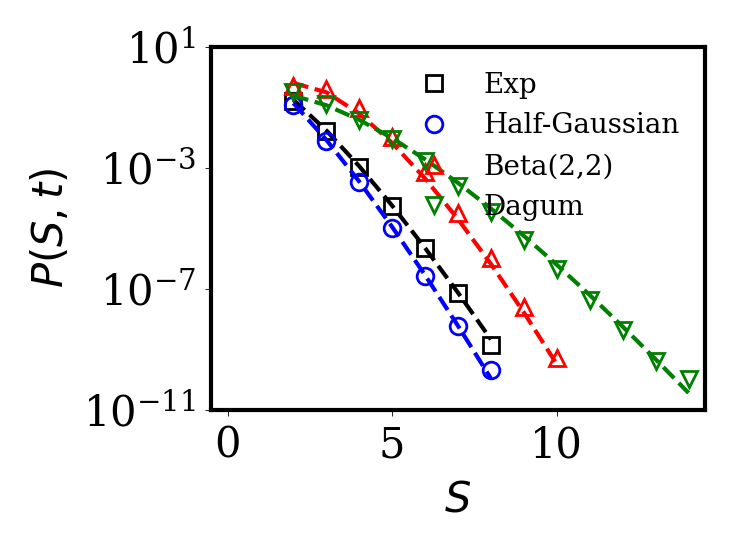

In [58]:
# -------------------------
# Parameters (change here)
# -------------------------
import pandas as pd


N = 1000                 # graph size
n_walkers = 1000000        # number of simulated walkers (reduce for speed)
rate = 2.0               # lambda
T_fixed = 1
start_node = 0           # starting node index for walkers (0..N-1)
p = 0.1
r,h=3,6
m=4
# Generate connected ER graph
while True:
    G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,seed=4)
    #G = nx.cycle_graph(N)
    #G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets = preprocess_graph(G)
N=len(G.nodes())
print("degree of 0 node =",G.degree(0))
print("Using graph with N =", N)
# -------------------------
# Run simulation
# -------------------------
start_time = time.time()
C0_hg = 2.0 / (5.0 * np.pi)
dist_types = [0,1, 2, 3]
T_values = [.1,1., 1.0, 1]  # as in your figure
labels = ["Exp", "Half-Gaussian", "Beta(2,2)", "Dagum"]
col=["k--","b--","r--","g--"]
As=[0,0,1,0]
C_As=[rate,C0_hg,6,1]
C_Ap1s=[-(rate**2),0,-6,-2]
scol=["k","b","r","g"]
simcol=["s","o","^","v"]
plt.figure(figsize=(3.675, 2.75),dpi=200)
for dist_type, T, label,A,C_A,C_Ap1 in zip(dist_types, T_values, labels,As,C_As,C_Ap1s):
     
    counts = simulate_distinct_counts(
        T=T,
        n_walkers=10000000000,
        nodes=nodes,
        edges_flat=edges_flat,
        offsets=offsets,
        N=N,
        dist_type=dist_type,
        start_node=0,
        rate=rate
    )
    max_visits = int(np.max(counts))
    v_vals = np.arange(1, max_visits + 1)
    hist = np.bincount(counts, minlength=max_visits + 1)[1:]  # ignore 0
    hist_prob = hist / np.sum(hist)
    Q_ldp_pref, _, _ = Qt_large_dev_logs(T, v_vals-1, A, C_A, C_Ap1, with_prefactor=True)
    # After computing v_vals, hist_prob
    df = pd.DataFrame({
        "S": v_vals[1:],         # skip S=0
        "P_sim": hist_prob[1:],  # simulation
        "P_ld": Q_ldp_pref[1:]   # large deviation prediction
    })

    filename = f"ERD_Qt_dist_n_walkers_{n_walkers}{label}.csv"
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")
    plt.semilogy(v_vals[1:], hist_prob[1:],color=scol[dist_type],linestyle='none',marker=simcol[dist_type],mfc='none', label=label)
    plt.semilogy(v_vals[1:], Q_ldp_pref[1:], col[dist_type], markersize=6)
plt.xlabel(r"$S$")
plt.ylabel(r"$P(S,t)$")
plt.xlim(-0.5, 14.5)
plt.ylim(1e-11, 10.0)
plt.legend(frameon=False,fontsize=10)
plt.tight_layout()
plt.show()


In [43]:
#plt.xticks([1,3,5,7,9,11,13,15])
plt.xticks([2,4,6,8,10,12,14])
plt.yticks([1,0.01,0.0001,0.000001,0.00000001,0.0000000001])
plt.xlim(0.8,14.5)
plt.ylim(0.00000000003,3)
plt.legend(frameon=False,fontsize=10)
plt.tight_layout()

In [14]:
plt.xlim(-0.5, 14.5)
plt.ylim(1e-9, 10.0)

(1e-09, 10.0)

In [23]:
plt.savefig(f"./fig/BA_N_1000_m_4_t_point1_rate_2__walker_10000000000_t_p1_1_1_1_LDP0.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [20]:
plt.savefig(f"./fig/ER_N_1000_P_point01_t_point1_rate_2__walker_1000000000_t_p1_1_1_1_LDP.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [26]:
plt.savefig(f"./fig/Complete_N_1000_rate_2__walker_1000000000_t_p1_1_1_1_LDP.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

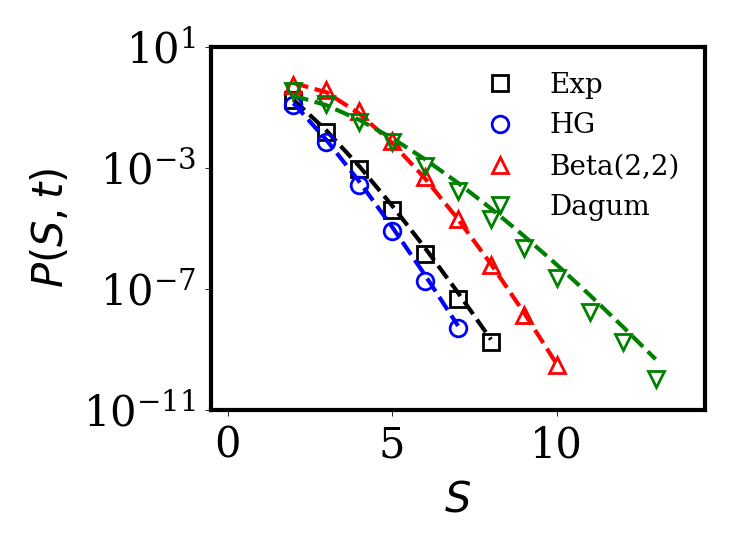

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
i=1
n_walkers=1000000
ram=["complete_net","ERS","ERD","BA"]
files = [
    (f"{ram[i]}_Qt_dist_n_walkers_{n_walkers}Exp.csv", "k", "s", "Exp"),
    (f"{ram[i]}_Qt_dist_n_walkers_{n_walkers}Half-Gaussian.csv", "b", "o", "HG"),
    (f"{ram[i]}_Qt_dist_n_walkers_{n_walkers}Beta(2,2).csv", "r", "^", "Beta(2,2)"),
    (f"{ram[i]}_Qt_dist_n_walkers_{n_walkers}Dagum.csv", "g", "v", "Dagum")
]

plt.figure(figsize=(3.675, 2.75), dpi=200)

for fname, col, marker, label in files:
    df = pd.read_csv(fname)
    S = df["S"].values
    P_sim = df["P_sim"].values
    P_ld = df["P_ld"].values

    # Plot simulation
    plt.semilogy(S, P_sim, color=col, linestyle='none', marker=marker,
                 mfc='none', label=label)

    # Plot LD curve
    plt.semilogy(S, P_ld, col + '--')

plt.xlabel(r"$S$")
plt.ylabel(r"$P(S,t)$")
plt.xlim(-0.5, 14.5)
plt.ylim(1e-11, 10)

plt.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


In [136]:
#plt.xticks([1,3,5,7,9,11,13,15])
plt.xticks([2,4,6,8,10,12,14])
plt.yticks([1,0.01,0.0001,0.000001,0.00000001,0.0000000001])
plt.xlim(1,14.5)
plt.ylim(0.00000000003,4)
plt.legend(frameon=False,fontsize=10)
ax=plt.gca()
plt.text(0.12, 0.15, "(a)", transform=ax.transAxes, fontsize=14, va='top')
plt.tight_layout()

In [125]:
plt.savefig(f"./fig/Complete_N_1000_rate_2__walker_{n_walkers}_t_p1_1_1_1_LDP.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [139]:
plt.savefig(f"./fig/ER_N_1000_P_point01_t_point1_rate_2__walker_{n_walkers}_t_p1_1_1_1_LDP.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [132]:
plt.savefig(f"./fig/BA_N_1000_m_4_t_point1_rate_2__walker_{n_walkers}_t_p1_1_1_1_LDP0.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)